In [64]:
import paarti.utils.maos_utils as mu
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import glob
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
import os

In [23]:
def centroid(psf, verbose:bool=False):
    # Calculate statistics on image prior to processing
    _, median, std = sigma_clipped_stats(psf, sigma=3.0) 
    # NIRC2/OSIRIS have FWHM of 5 pixels
    try:
        daofind = DAOStarFinder(fwhm=5.0, threshold=median + 50.0*std)
    except Exception as error:
        print(f"ERROR centroiding PSF : {error}")
    sources = daofind(psf)  
    if verbose:
        sources.pprint()

    # Find coordinates of brightest pixel
    coords = np.array([0.0, 0.0])
    coords[0] = sources['id'==np.argmax(sources['flux'])]['xcentroid']
    coords[1] = sources['id'==np.argmax(sources['flux'])]['ycentroid']
    return coords

In [14]:
epochs = ['2015may', '2015apr']
root = Path('/g/lu/data/m53/')
psf_fits = []
for epoch in epochs:
    # ~250 frames, don't want to simulate all, so store every 3rd file to simulate
    psf_fits.extend([f.as_posix() for f in root.glob(f"{epoch}/clean/kp/*_psf.fits")][::3])

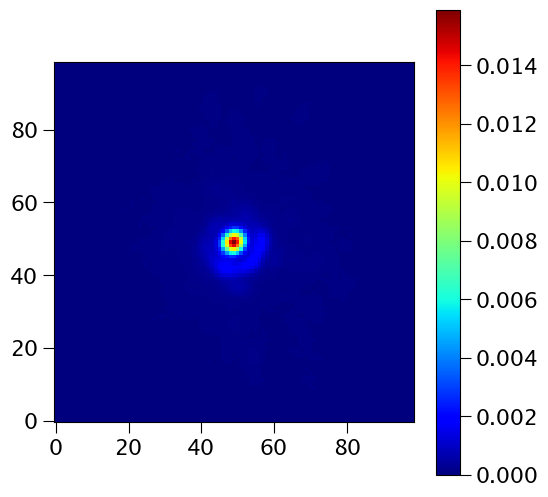

In [17]:
with fits.open(psf_fits[0]) as file:
    hdu = file[0]
    hdr = hdu.header
    img = hdu.data 

plt.imshow(img)
plt.colorbar()

Coordinates of Strehl source centered by convention as expected for PSFs

In [26]:
# Centroid on cleaned images
psf_coords = []
for filename in psf_fits:
    with fits.open(psf_fits[0]) as file:
        hdu = file[0]
        hdr = hdu.header
        img = hdu.data 

        coords = centroid(img)
        psf_coords.append(coords)

In [31]:
frames = np.column_stack((psf_fits, psf_coords))

Filter = Kp | Scale (arcsec/px) = 0.009952 | Wavelength (microns) = 2.124500 
box size going into fit_gaussian2d() : 21.0


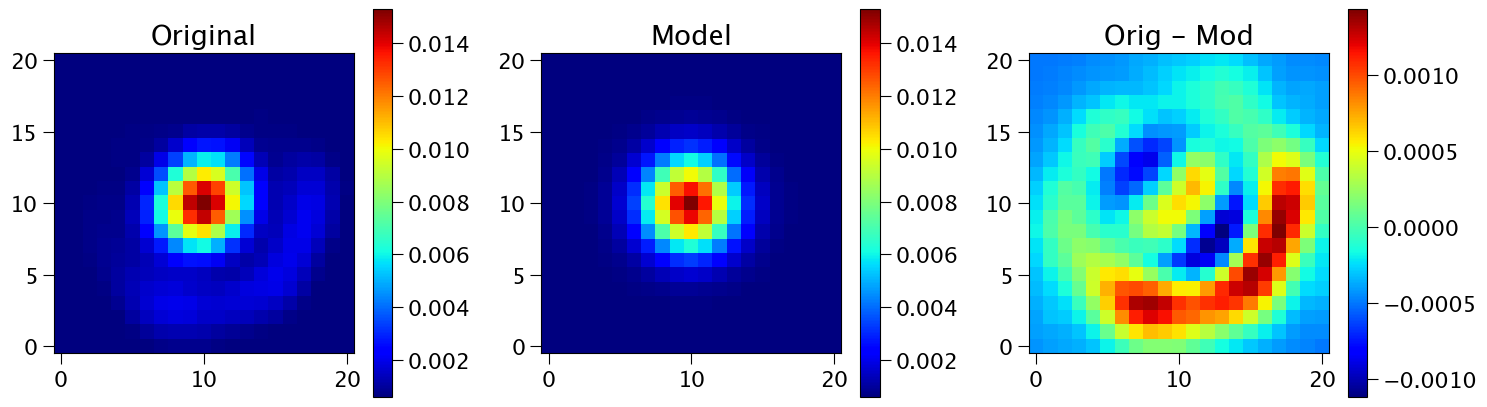

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0013_psf.fits 1 5.082730439442657 48.934678794432315 48.967019975513296 21.0
peak flux ratio =  0.015890144  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0013_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0013_psf.fits                  -1.000    -1.0   -1.00  57147.3141

box size going into fit_gaussian2d() : 21.0


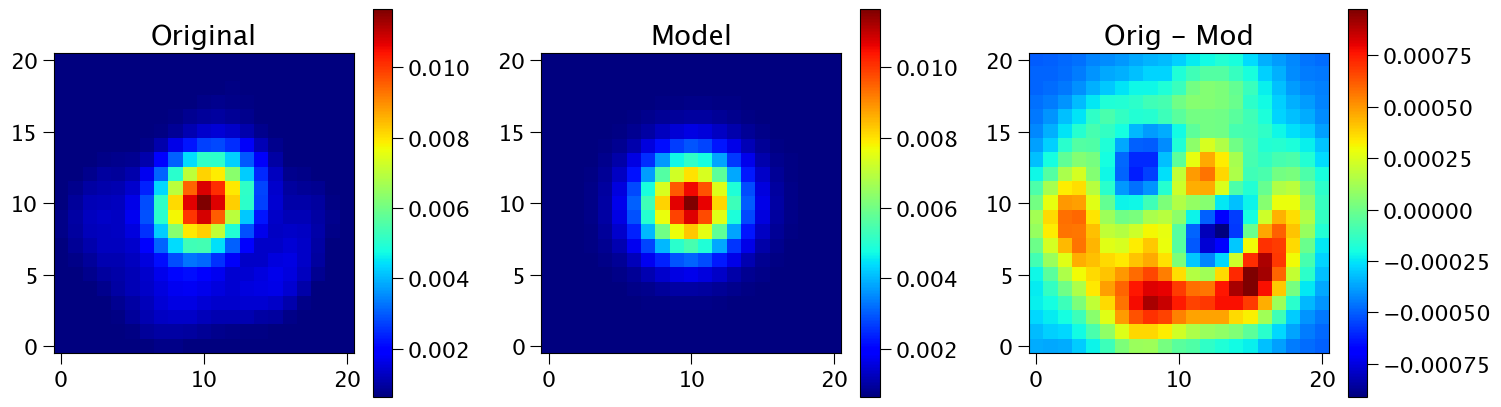

FWHM on iteration 1 = 53.71 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0016_psf.fits 1 5.397122719686581 48.992565808297535 48.94793950580627 21.0
peak flux ratio =  0.011795975  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0016_psf.fits   0.321   360.6   53.71   49.5   49.5

c0016_psf.fits                   0.321   360.6   53.71  57147.3179

box size going into fit_gaussian2d() : 21.0


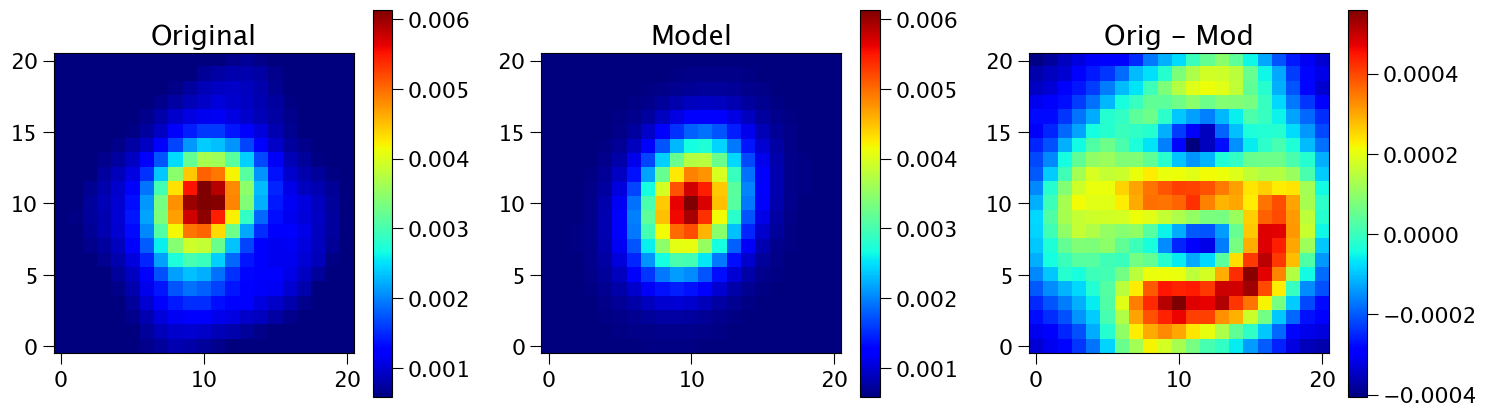

FWHM on iteration 1 = 63.53 mas | Empirical FWHM on iteration 1 = 65.4794292419564 mas
c0019_psf.fits 1 6.383321614328679 49.0038415971475 48.8496353548158 21.0
peak flux ratio =  0.006503503  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0019_psf.fits   0.177   445.1   63.53   49.5   49.5

c0019_psf.fits                   0.177   445.1   63.53  57147.3204

box size going into fit_gaussian2d() : 21.0


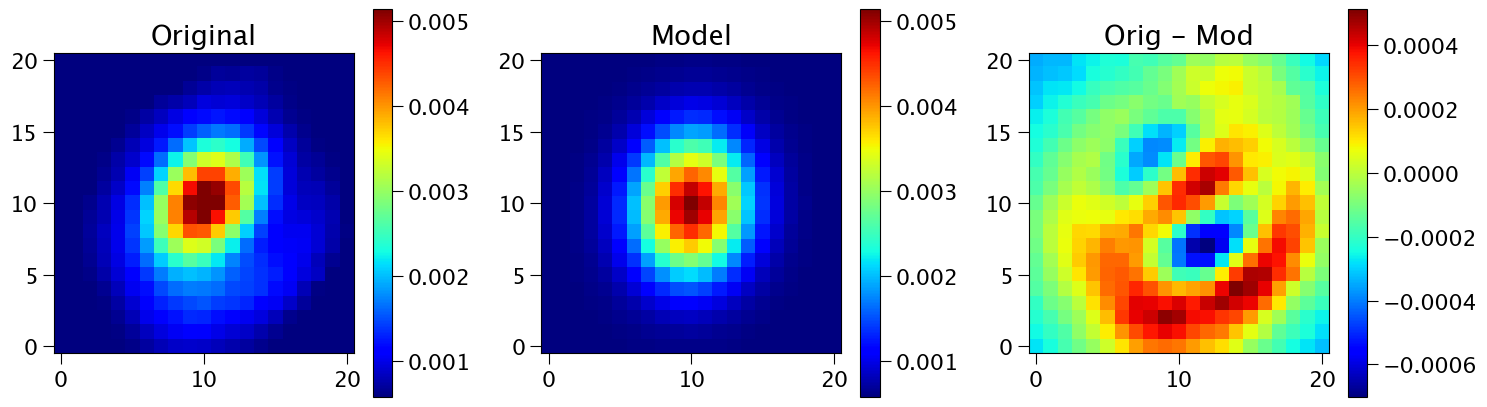

FWHM on iteration 1 = 69.79 mas | Empirical FWHM on iteration 1 = 70.12901356874188 mas
c0022_psf.fits 1 7.012368192030656 49.05002477321223 48.81685664058193 21.0
peak flux ratio =  0.0054853423  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0022_psf.fits   0.149   466.4   69.79   49.5   49.5

c0022_psf.fits                   0.149   466.4   69.79  57147.3230

box size going into fit_gaussian2d() : 21.0


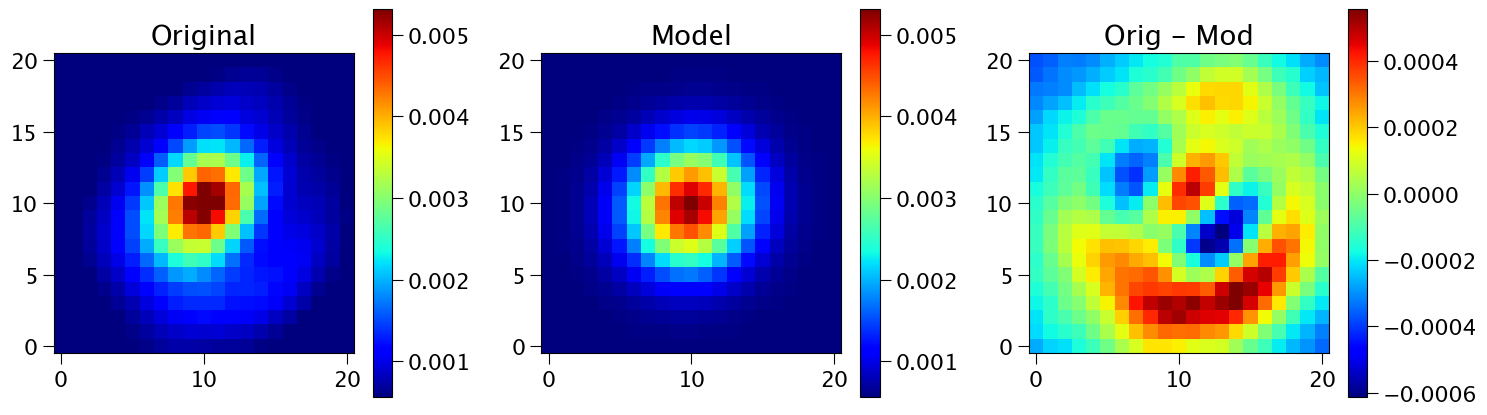

FWHM on iteration 1 = 66.64 mas | Empirical FWHM on iteration 1 = 69.22408515878199 mas
c0025_psf.fits 1 6.696092517249371 48.95712405538758 48.79814523703405 21.0
peak flux ratio =  0.005672938  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0025_psf.fits   0.154   462.3   66.64   49.5   49.5

c0025_psf.fits                   0.154   462.3   66.64  57147.3256

box size going into fit_gaussian2d() : 21.0


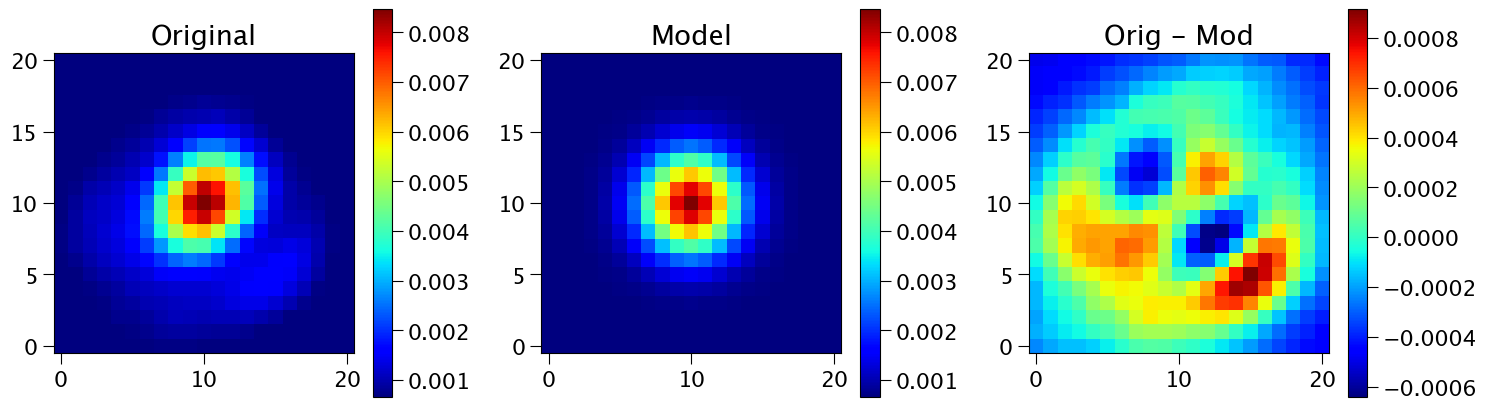

FWHM on iteration 1 = 55.22 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0028_psf.fits 1 5.548750503376519 48.99959018467213 48.99425502090422 21.0
peak flux ratio =  0.008718788  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0028_psf.fits   0.237   405.7   55.22   49.5   49.5

c0028_psf.fits                   0.237   405.7   55.22  57147.3306

box size going into fit_gaussian2d() : 21.0


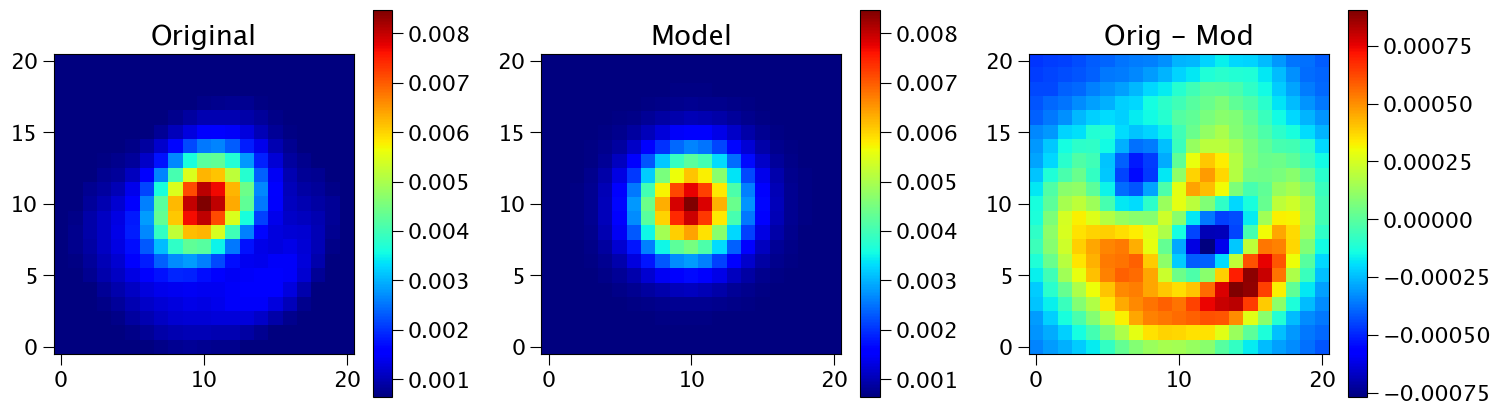

FWHM on iteration 1 = 57.90 mas | Empirical FWHM on iteration 1 = 55.0137244086197 mas
c0031_psf.fits 1 5.818352114642909 48.98347710795003 48.92784568098578 21.0
peak flux ratio =  0.008753676  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0031_psf.fits   0.238   405.1   57.90   49.5   49.5

c0031_psf.fits                   0.238   405.1   57.90  57147.3331

box size going into fit_gaussian2d() : 21.0


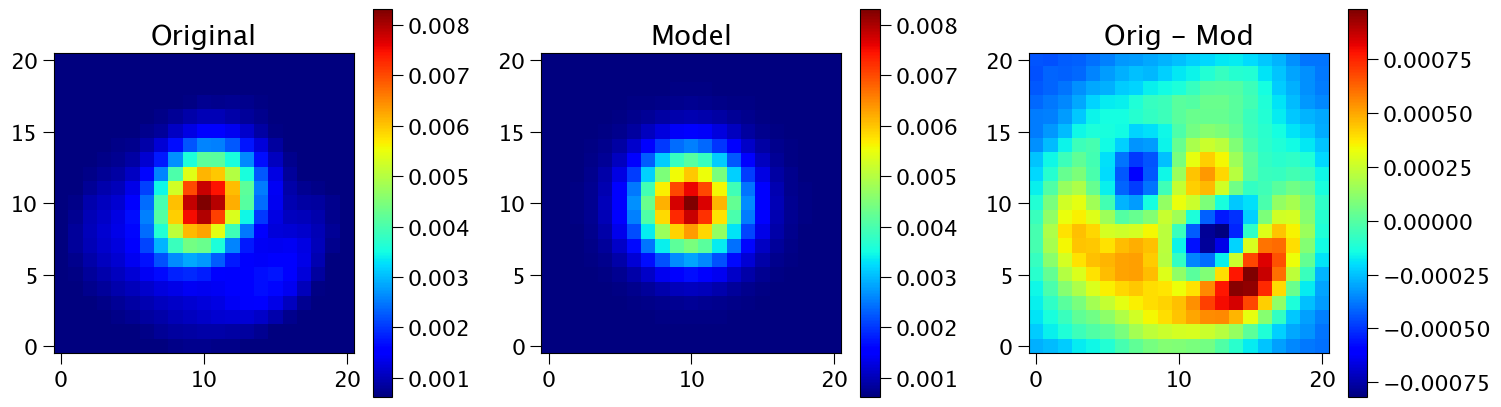

FWHM on iteration 1 = 57.65 mas | Empirical FWHM on iteration 1 = 55.0137244086197 mas
c0034_psf.fits 1 5.792738265210343 48.98601281859483 48.90084752602213 21.0
peak flux ratio =  0.008628159  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0034_psf.fits   0.235   407.1   57.65   49.5   49.5

c0034_psf.fits                   0.235   407.1   57.65  57147.3357

box size going into fit_gaussian2d() : 21.0


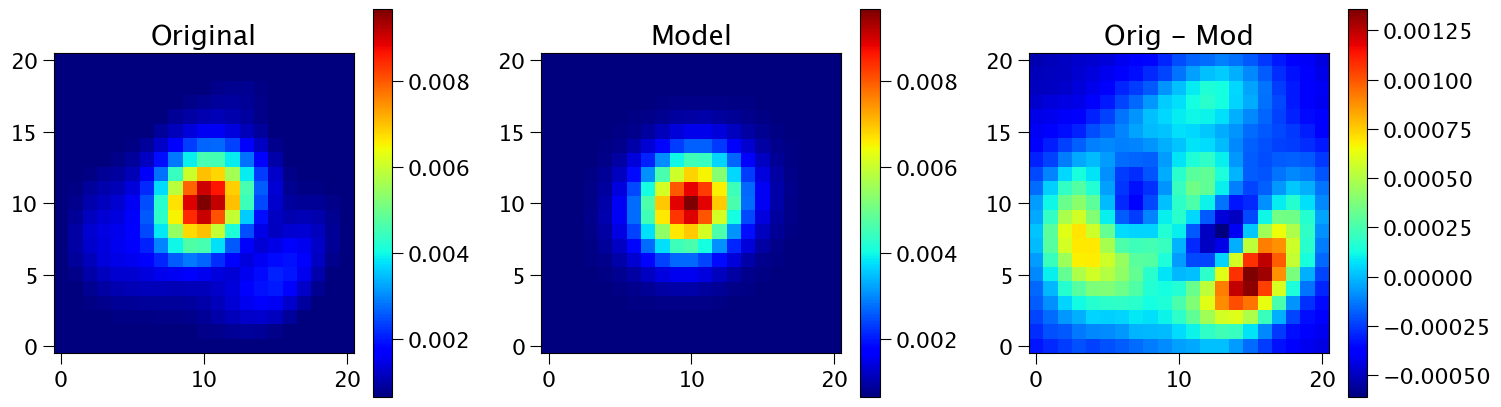

FWHM on iteration 1 = 54.87 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0037_psf.fits 1 5.513038851188091 48.991926128214175 48.97843477726615 21.0
peak flux ratio =  0.00985624  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0037_psf.fits   0.268   388.0   54.87   49.5   49.5

c0037_psf.fits                   0.268   388.0   54.87  57147.3383

box size going into fit_gaussian2d() : 21.0


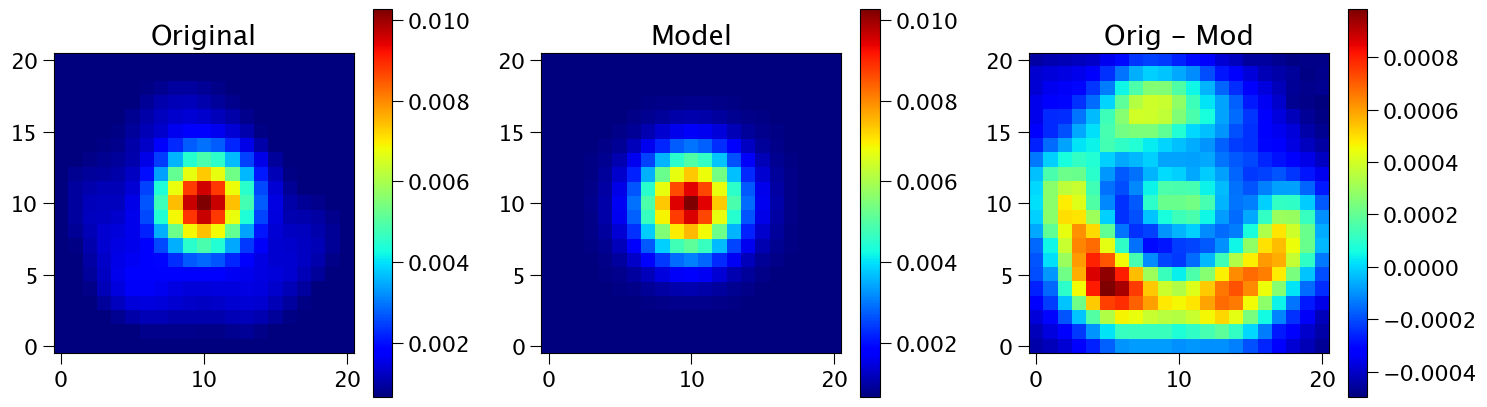

FWHM on iteration 1 = 55.42 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0040_psf.fits 1 5.569090075657837 48.98691662161579 48.96710715901504 21.0
peak flux ratio =  0.010477216  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0040_psf.fits   0.285   378.9   55.42   49.5   49.5

c0040_psf.fits                   0.285   378.9   55.42  57147.3475

box size going into fit_gaussian2d() : 21.0


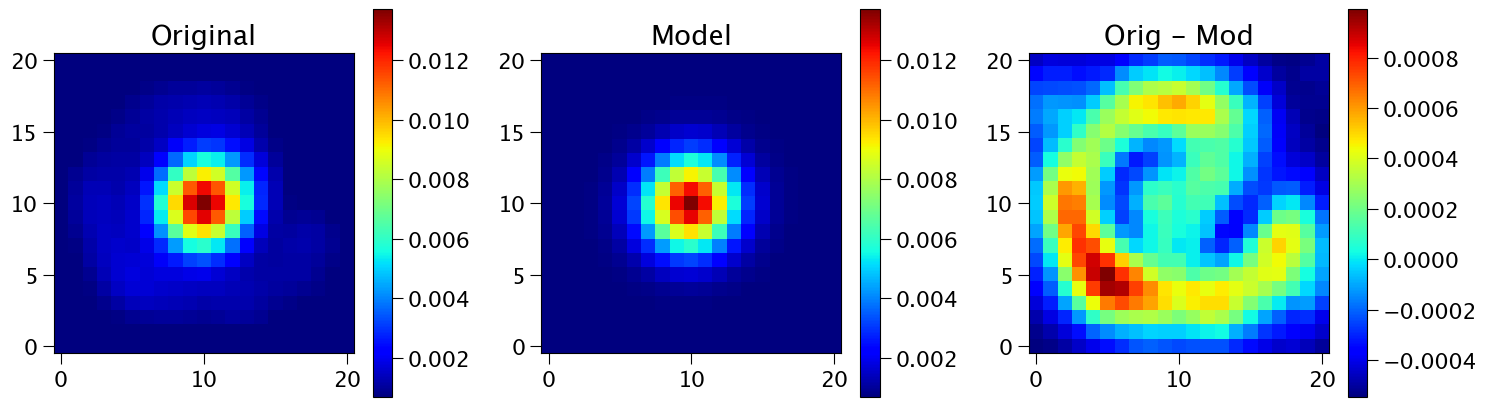

FWHM on iteration 1 = 51.42 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0043_psf.fits 1 5.166894337767908 48.973601301042535 48.96919470266132 21.0
peak flux ratio =  0.013765722  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0043_psf.fits   0.374   335.2   51.42   49.5   49.5

c0043_psf.fits                   0.374   335.2   51.42  57147.3501

box size going into fit_gaussian2d() : 21.0


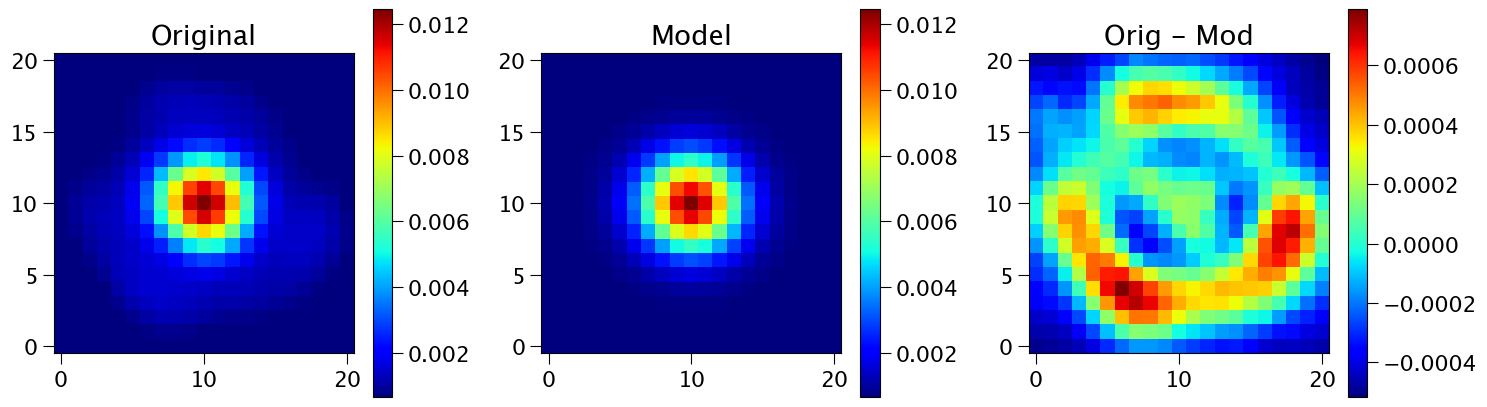

FWHM on iteration 1 = 53.89 mas | Empirical FWHM on iteration 1 = 52.67163104744902 mas
c0046_psf.fits 1 5.414903330748611 49.00340690591007 48.9812765718229 21.0
peak flux ratio =  0.012631399  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0046_psf.fits   0.343   349.6   53.89   49.5   49.5

c0046_psf.fits                   0.343   349.6   53.89  57147.3545

box size going into fit_gaussian2d() : 21.0


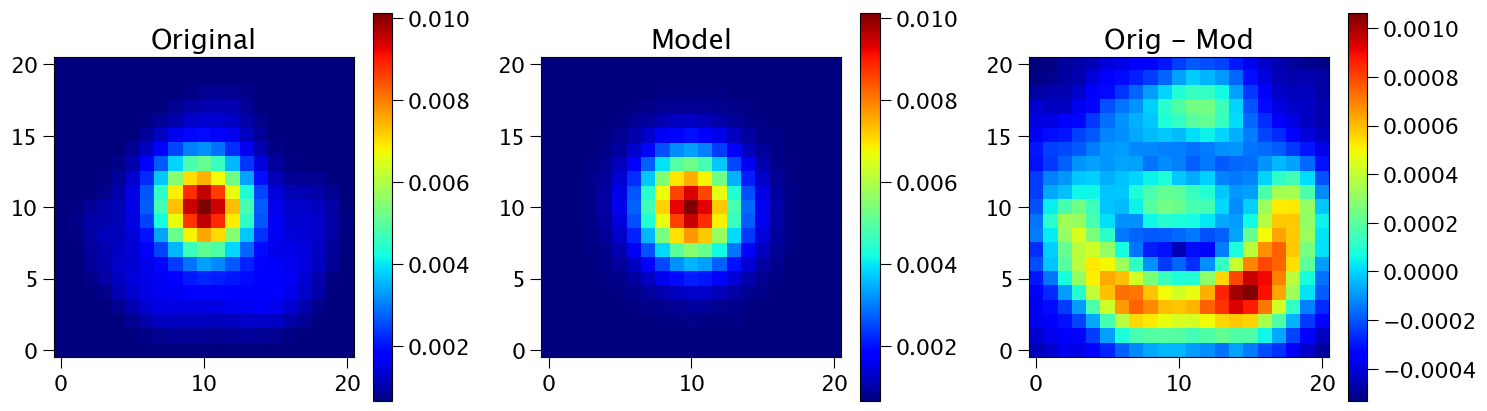

FWHM on iteration 1 = 57.05 mas | Empirical FWHM on iteration 1 = 56.14814735467271 mas
c0049_psf.fits 1 5.732199720120942 49.01836809456349 48.94187844010564 21.0
peak flux ratio =  0.010343197  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0049_psf.fits   0.281   380.8   57.05   49.5   49.5

c0049_psf.fits                   0.281   380.8   57.05  57147.3571

box size going into fit_gaussian2d() : 21.0


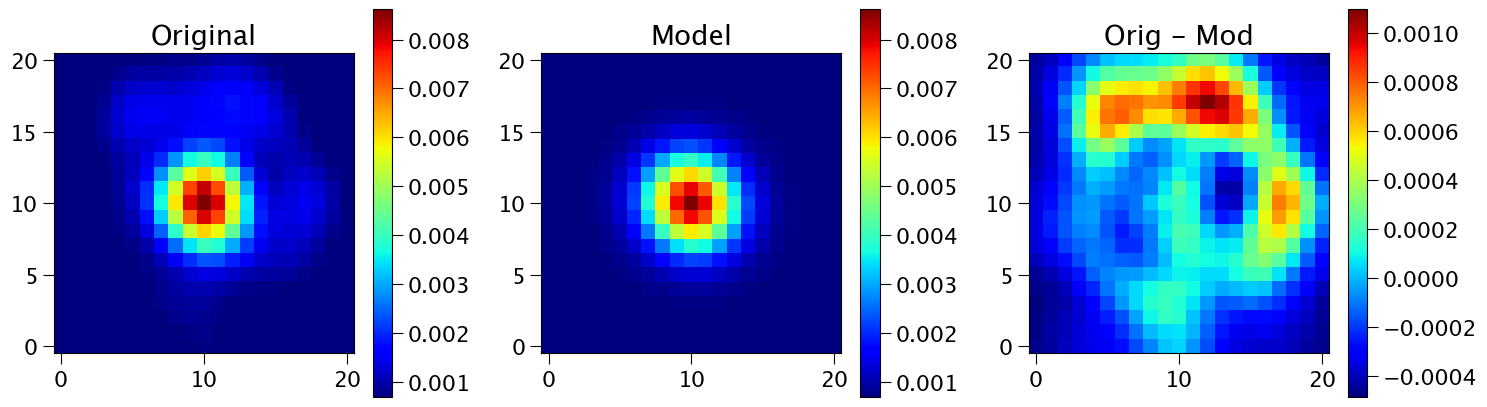

FWHM on iteration 1 = 52.02 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0064_psf.fits 1 5.227209633958664 49.0176874343595 49.02945560486138 21.0
peak flux ratio =  0.008789401  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0064_psf.fits   0.239   404.5   52.02   49.5   49.5

c0064_psf.fits                   0.239   404.5   52.02  57147.3774

box size going into fit_gaussian2d() : 21.0


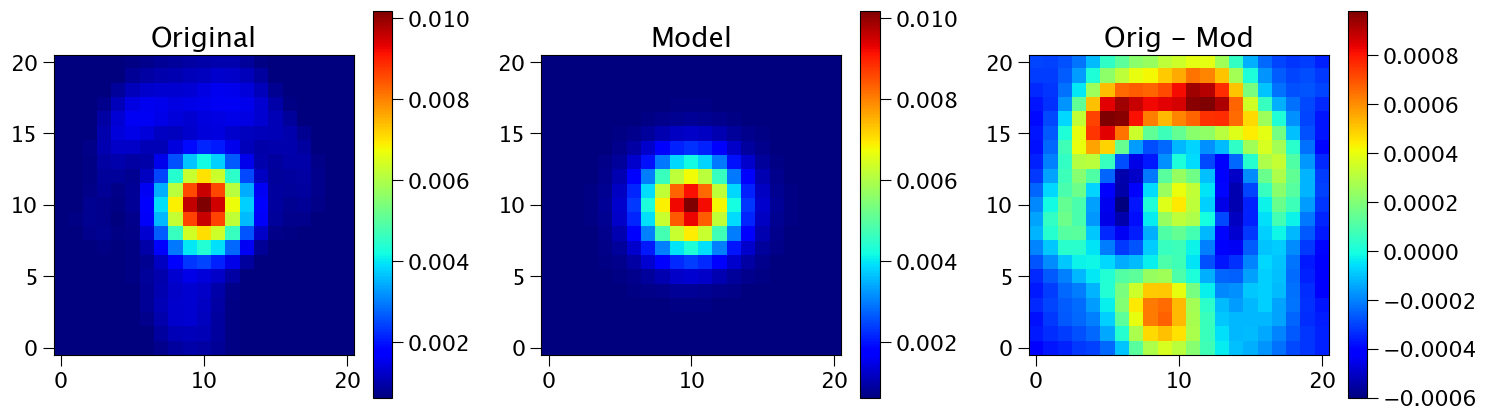

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0067_psf.fits 1 5.082730439442657 48.98791200921987 48.97265414751134 21.0
peak flux ratio =  0.010627803  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0067_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0067_psf.fits                  -1.000    -1.0   -1.00  57147.3810

box size going into fit_gaussian2d() : 21.0


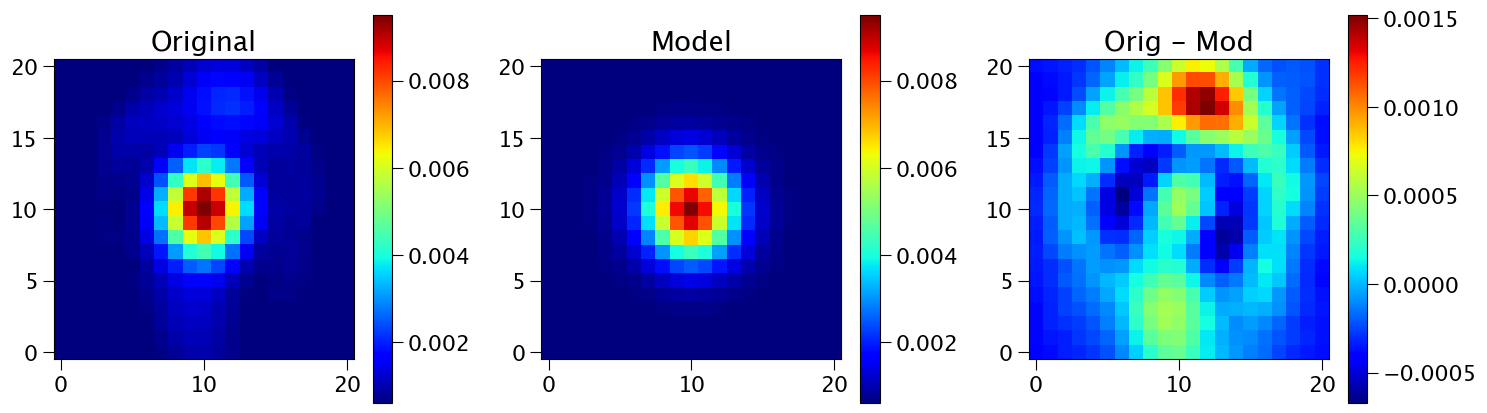

FWHM on iteration 1 = 52.05 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0070_psf.fits 1 5.2299598778740295 48.98637260499101 48.97916708983251 21.0
peak flux ratio =  0.010005689  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0070_psf.fits   0.272   385.8   52.05   49.5   49.5

c0070_psf.fits                   0.272   385.8   52.05  57147.3836

box size going into fit_gaussian2d() : 21.0


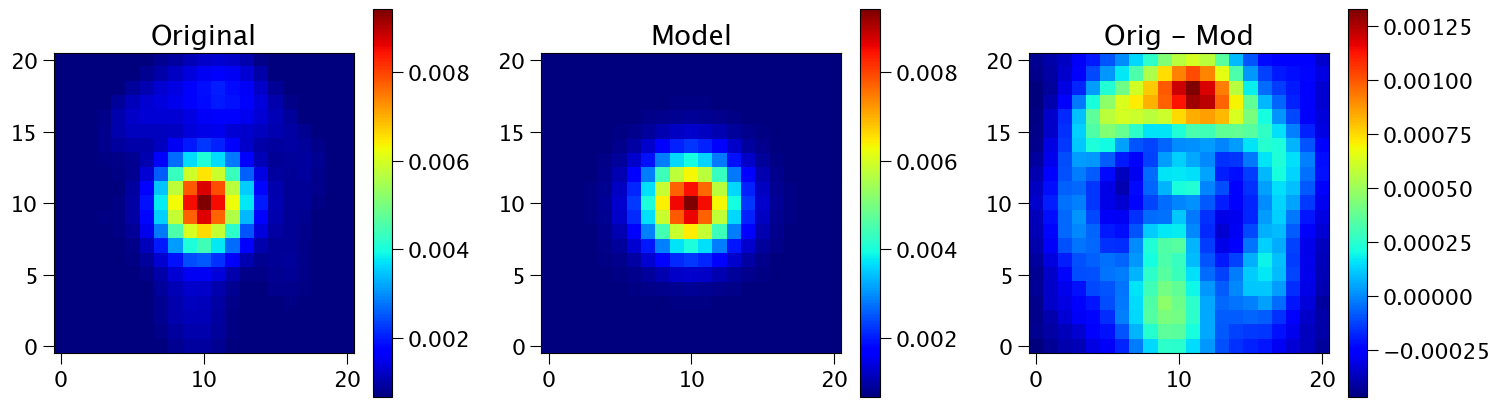

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0073_psf.fits 1 5.082730439442657 48.982416895104855 48.9782296659553 21.0
peak flux ratio =  0.009413126  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0073_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0073_psf.fits                  -1.000    -1.0   -1.00  57147.3861

box size going into fit_gaussian2d() : 21.0


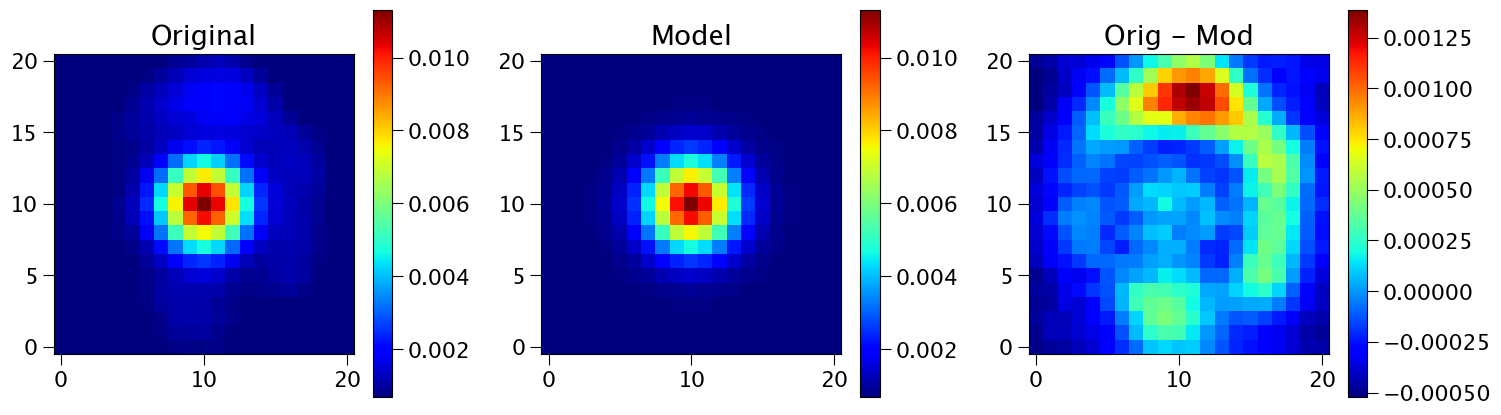

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0076_psf.fits 1 5.082730439442657 49.02889628486786 49.010809454275716 21.0
peak flux ratio =  0.011377517  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0076_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0076_psf.fits                  -1.000    -1.0   -1.00  57147.3891

box size going into fit_gaussian2d() : 21.0


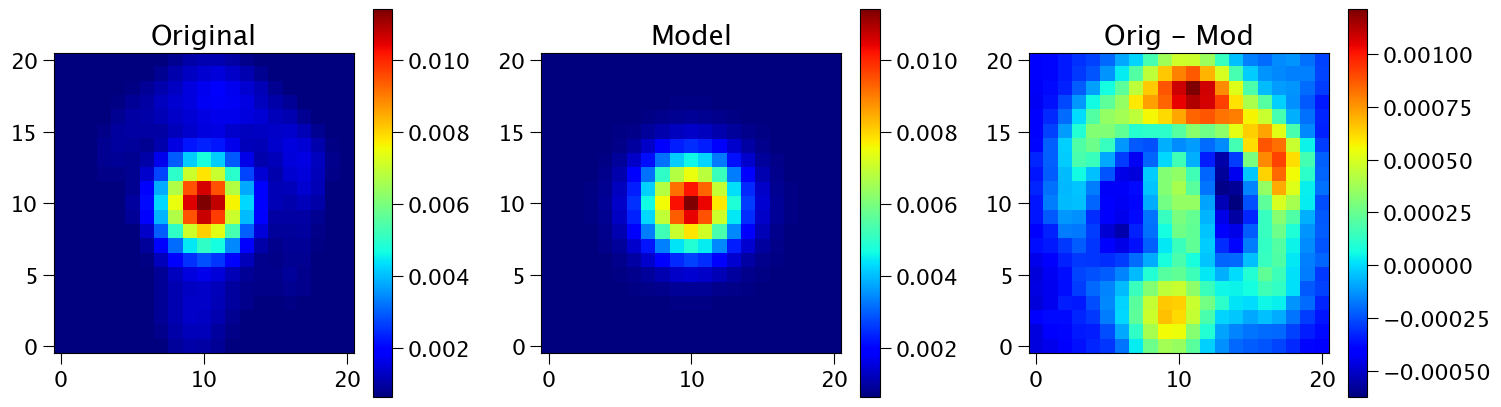

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0079_psf.fits 1 5.082730439442657 49.035417263572015 48.94691482347923 21.0
peak flux ratio =  0.011748299  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0079_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0079_psf.fits                  -1.000    -1.0   -1.00  57147.3917

box size going into fit_gaussian2d() : 21.0


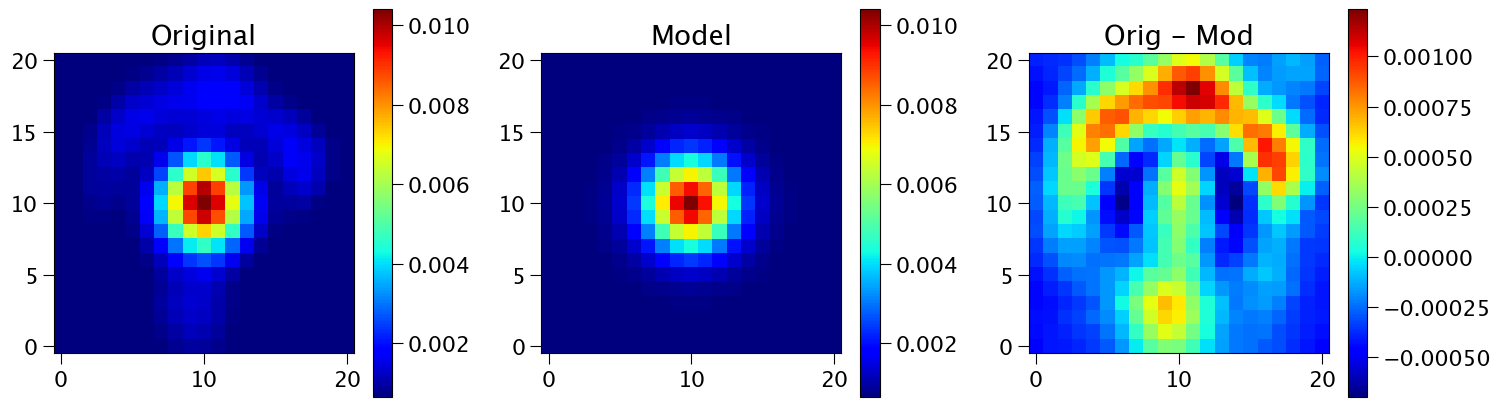

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0082_psf.fits 1 5.082730439442657 48.977901813285676 48.99691922468697 21.0
peak flux ratio =  0.010807752  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0082_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0082_psf.fits                  -1.000    -1.0   -1.00  57147.3943

box size going into fit_gaussian2d() : 21.0


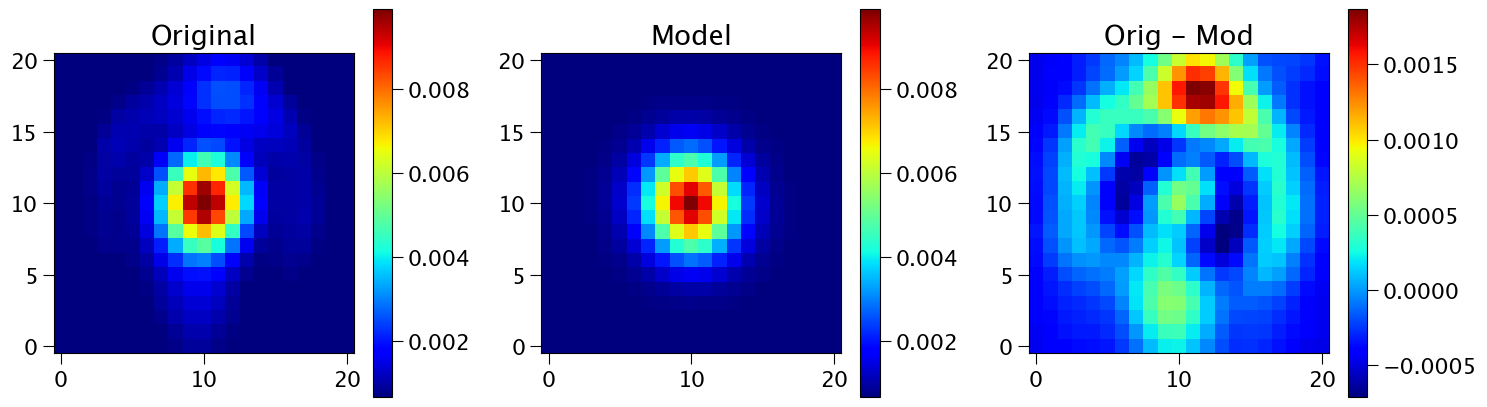

FWHM on iteration 1 = 52.86 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0094_psf.fits 1 5.311237605167573 48.99962007158329 48.995502760073514 21.0
peak flux ratio =  0.010565432  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0094_psf.fits   0.287   377.6   52.86   49.5   49.5

c0094_psf.fits                   0.287   377.6   52.86  57147.4063

box size going into fit_gaussian2d() : 21.0


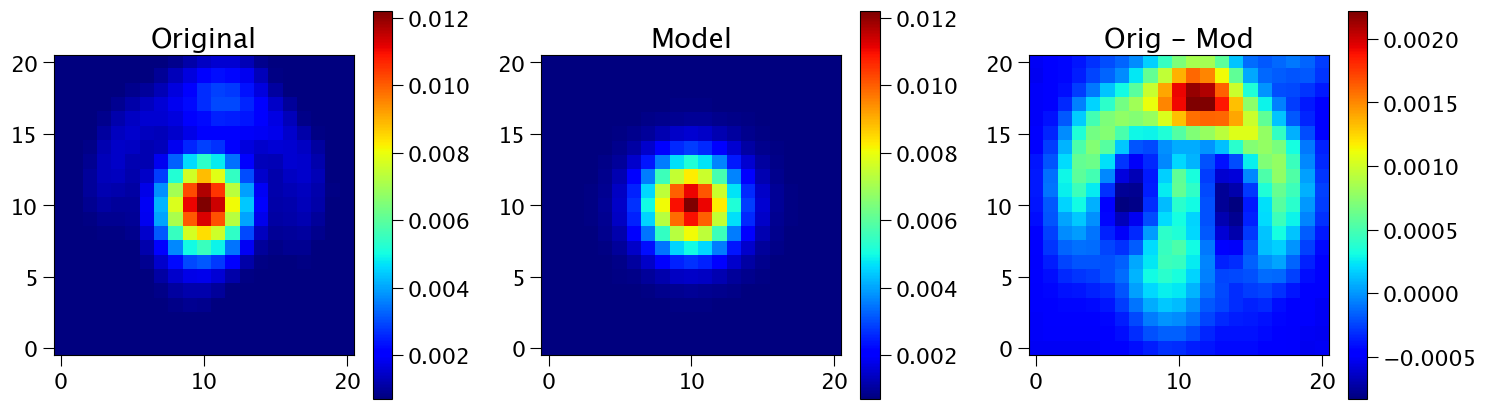

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0097_psf.fits 1 5.082730439442657 49.02978577077131 49.02895102595138 21.0
peak flux ratio =  0.012573753  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0097_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0097_psf.fits                  -1.000    -1.0   -1.00  57147.4089

box size going into fit_gaussian2d() : 21.0


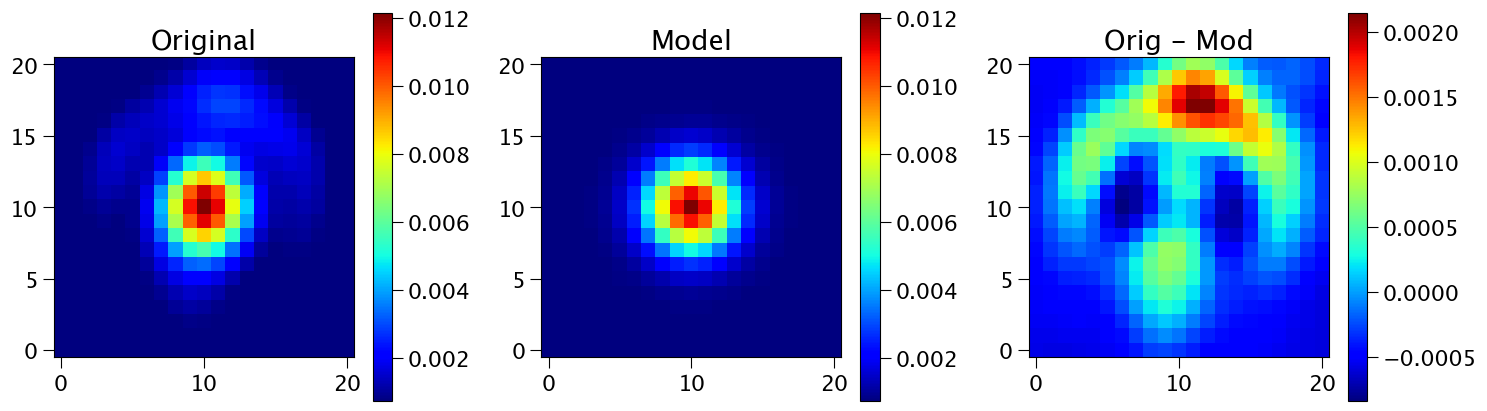

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0100_psf.fits 1 5.082730439442657 49.031270639606156 49.03158760013498 21.0
peak flux ratio =  0.012305105  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0100_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0100_psf.fits                  -1.000    -1.0   -1.00  57147.4115

box size going into fit_gaussian2d() : 21.0


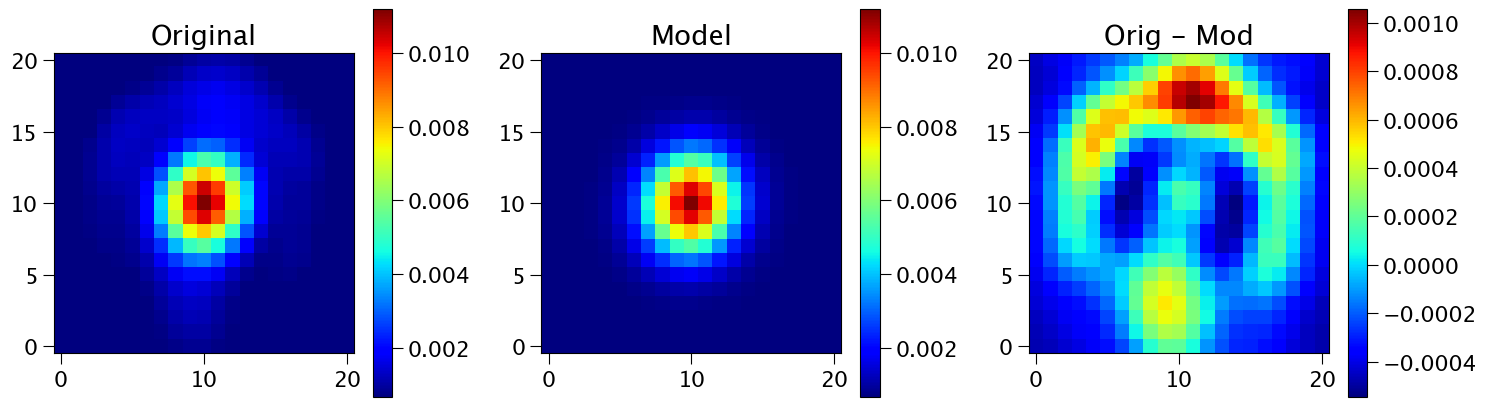

FWHM on iteration 1 = 53.30 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0103_psf.fits 1 5.355906575468685 49.008083585120254 49.01024537311614 21.0
peak flux ratio =  0.011296498  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0103_psf.fits   0.307   367.4   53.30   49.5   49.5

c0103_psf.fits                   0.307   367.4   53.30  57147.4158

box size going into fit_gaussian2d() : 21.0


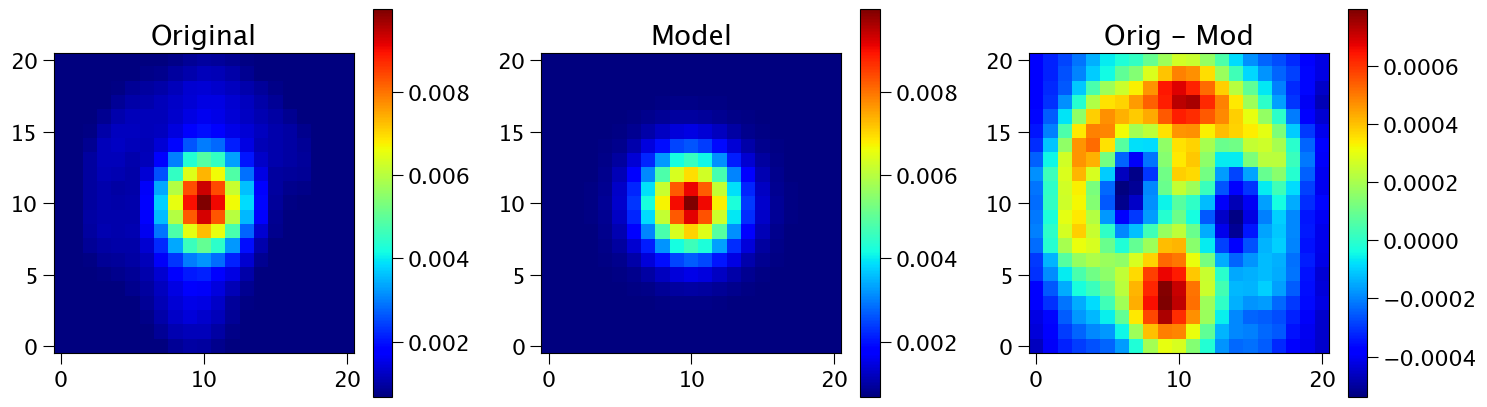

FWHM on iteration 1 = 52.01 mas | Empirical FWHM on iteration 1 = 52.67163104744902 mas
c0106_psf.fits 1 5.226409495249453 49.01056038961352 48.98134969427706 21.0
peak flux ratio =  0.010049891  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0106_psf.fits   0.273   385.1   52.01   49.5   49.5

c0106_psf.fits                   0.273   385.1   52.01  57147.4185

box size going into fit_gaussian2d() : 21.0


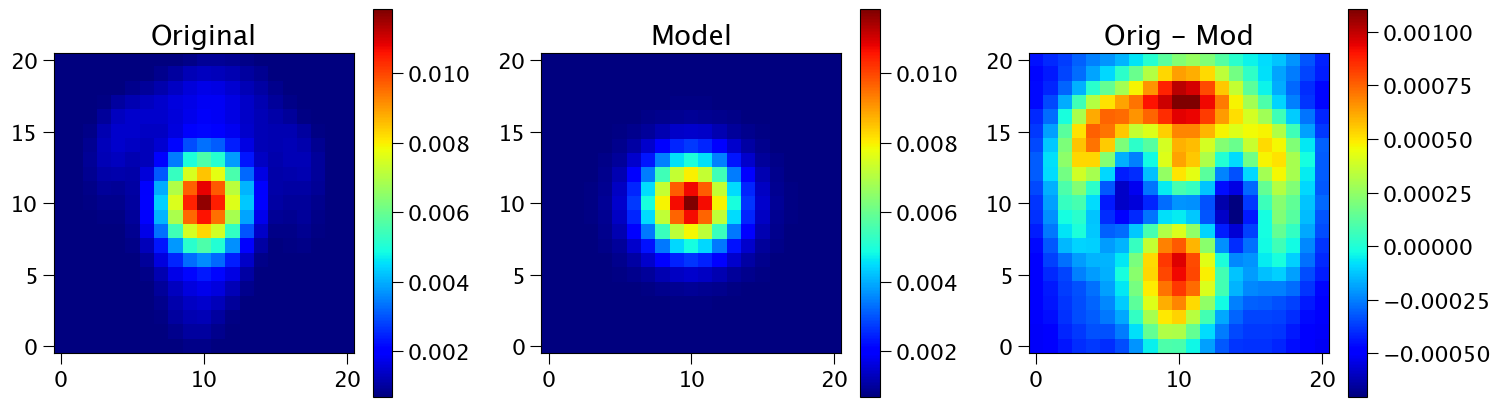

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0109_psf.fits 1 5.082730439442657 48.99909866814653 49.018780745789584 21.0
peak flux ratio =  0.011623903  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0109_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0109_psf.fits                  -1.000    -1.0   -1.00  57147.4211

box size going into fit_gaussian2d() : 21.0


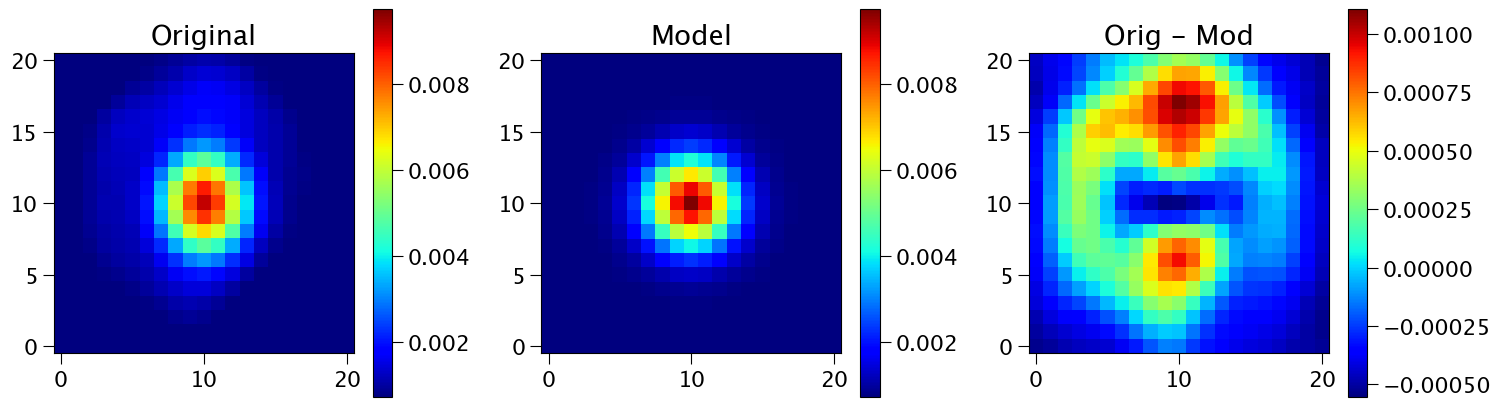

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 58.350866381494306 mas
c0112_psf.fits 1 5.082730439442657 49.00400369529829 49.03977781845897 21.0
peak flux ratio =  0.009177669  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0112_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0112_psf.fits                  -1.000    -1.0   -1.00  57147.4257

box size going into fit_gaussian2d() : 21.0


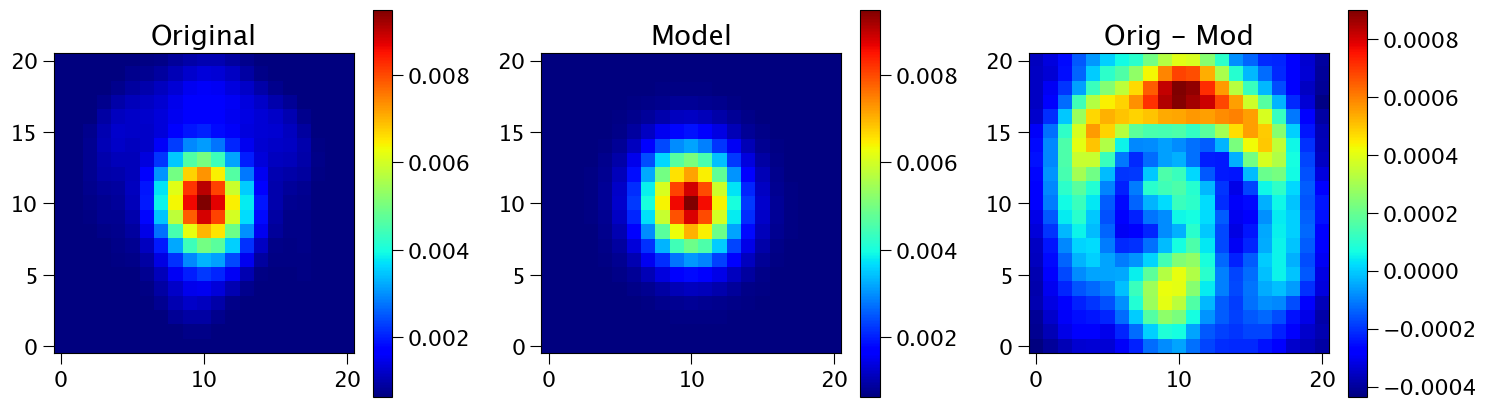

FWHM on iteration 1 = 54.80 mas | Empirical FWHM on iteration 1 = 56.14814735467271 mas
c0115_psf.fits 1 5.506134016383802 48.998533670414616 49.03282624760392 21.0
peak flux ratio =  0.009617886  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0115_psf.fits   0.262   391.6   54.80   49.5   49.5

c0115_psf.fits                   0.262   391.6   54.80  57147.4282

box size going into fit_gaussian2d() : 21.0


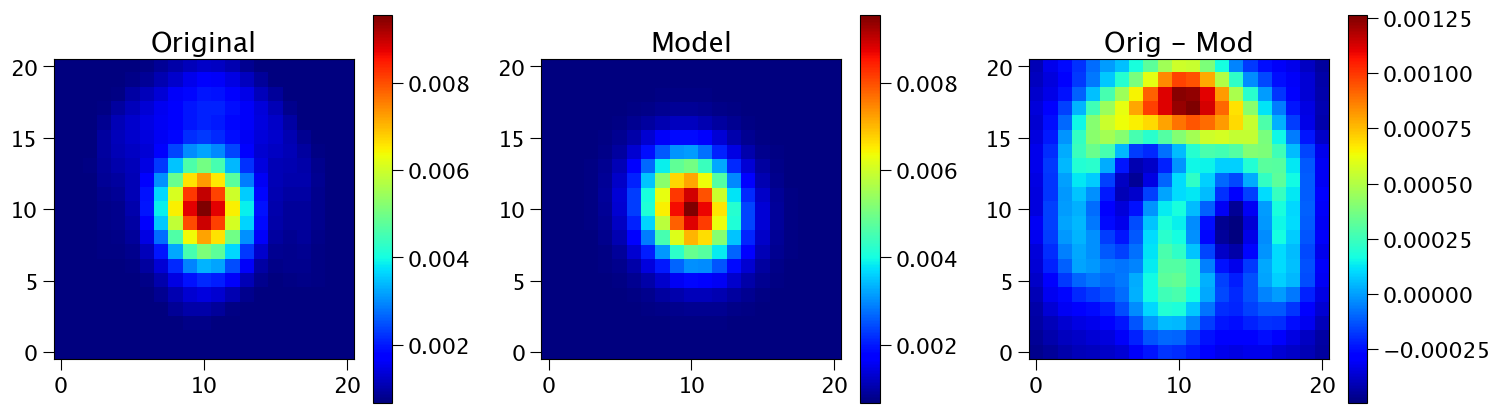

FWHM on iteration 1 = 55.11 mas | Empirical FWHM on iteration 1 = 56.14814735467271 mas
c0118_psf.fits 1 5.5372958762306475 49.01701904317392 49.0316702169361 21.0
peak flux ratio =  0.009714123  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0118_psf.fits   0.264   390.1   55.11   49.5   49.5

c0118_psf.fits                   0.264   390.1   55.11  57147.4308

box size going into fit_gaussian2d() : 21.0


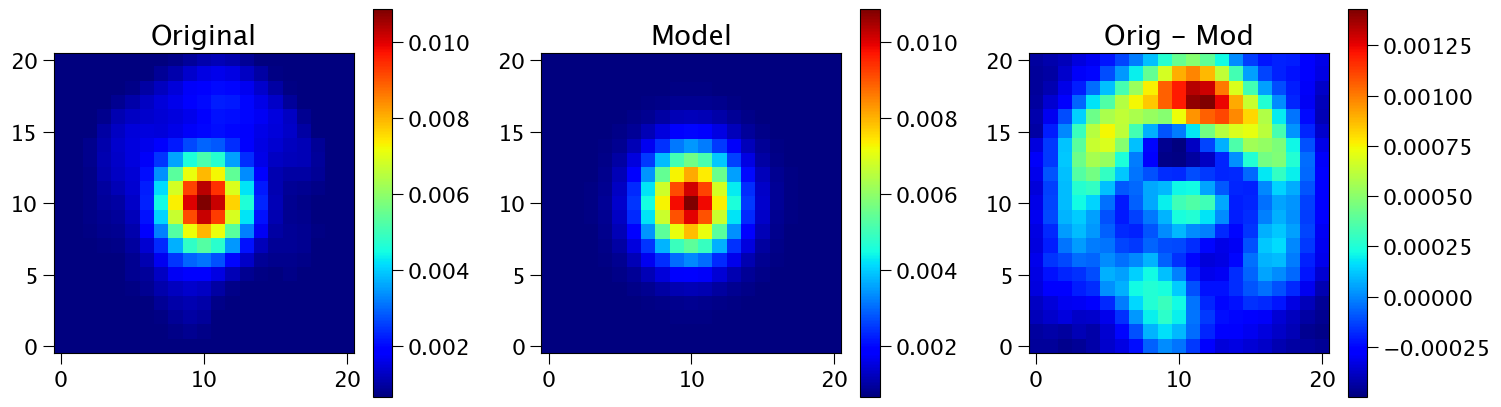

FWHM on iteration 1 = 54.10 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0121_psf.fits 1 5.435780180667836 49.00944993466203 49.044852634789194 21.0
peak flux ratio =  0.011189166  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0121_psf.fits   0.304   368.8   54.10   49.5   49.5

c0121_psf.fits                   0.304   368.8   54.10  57147.4362

box size going into fit_gaussian2d() : 21.0


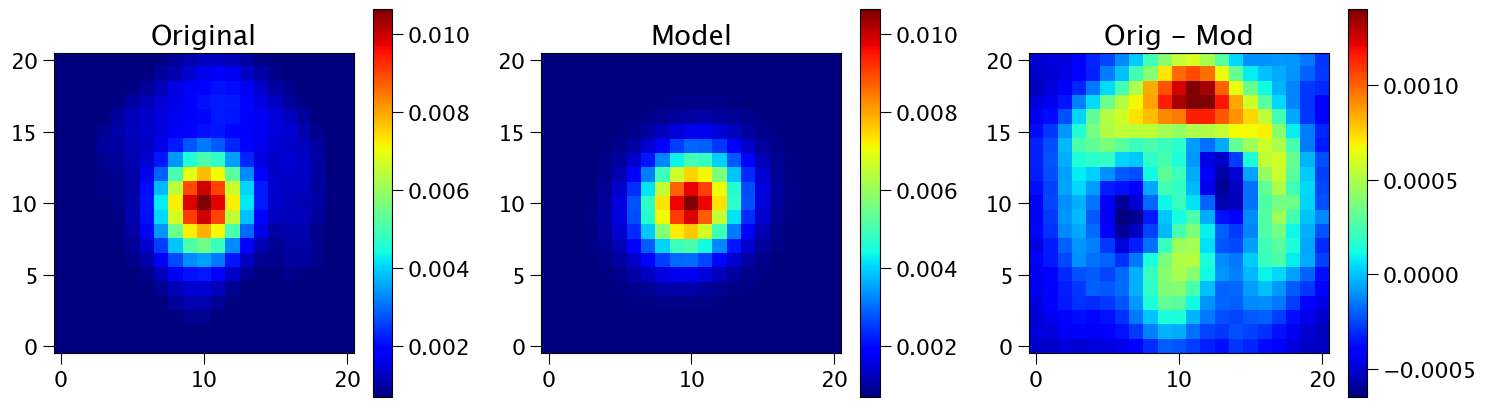

FWHM on iteration 1 = 53.76 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0124_psf.fits 1 5.401441240857928 48.99786006281296 48.98190735827897 21.0
peak flux ratio =  0.010849436  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0124_psf.fits   0.295   373.6   53.76   49.5   49.5

c0124_psf.fits                   0.295   373.6   53.76  57147.4388

box size going into fit_gaussian2d() : 21.0


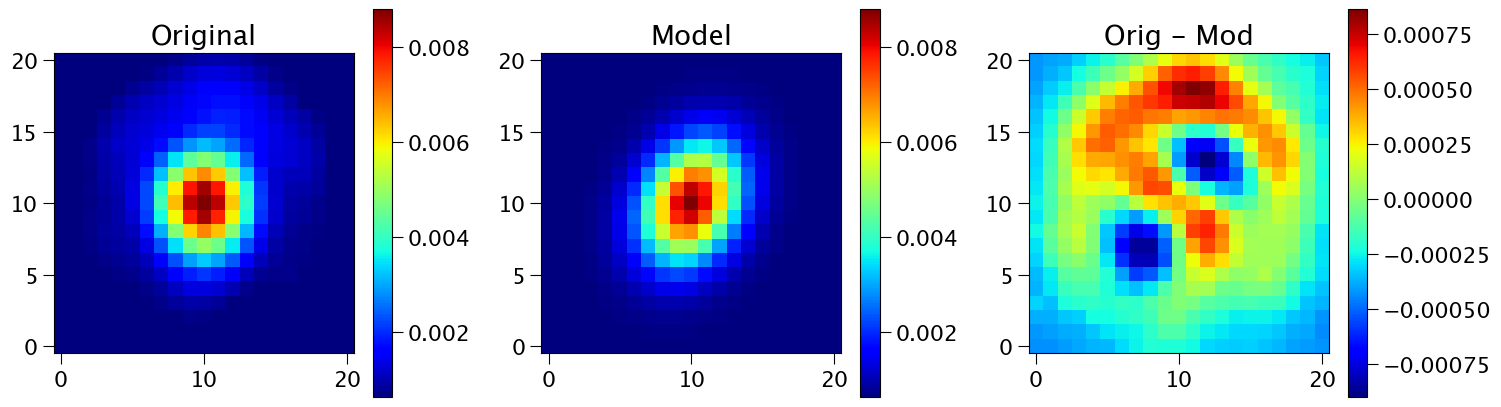

FWHM on iteration 1 = 59.62 mas | Empirical FWHM on iteration 1 = 58.350866381494306 mas
c0127_psf.fits 1 5.990681154706864 49.00898504499413 49.05538862121503 21.0
peak flux ratio =  0.00917699  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0127_psf.fits   0.250   398.4   59.62   49.5   49.5

c0127_psf.fits                   0.250   398.4   59.62  57147.4414

box size going into fit_gaussian2d() : 21.0


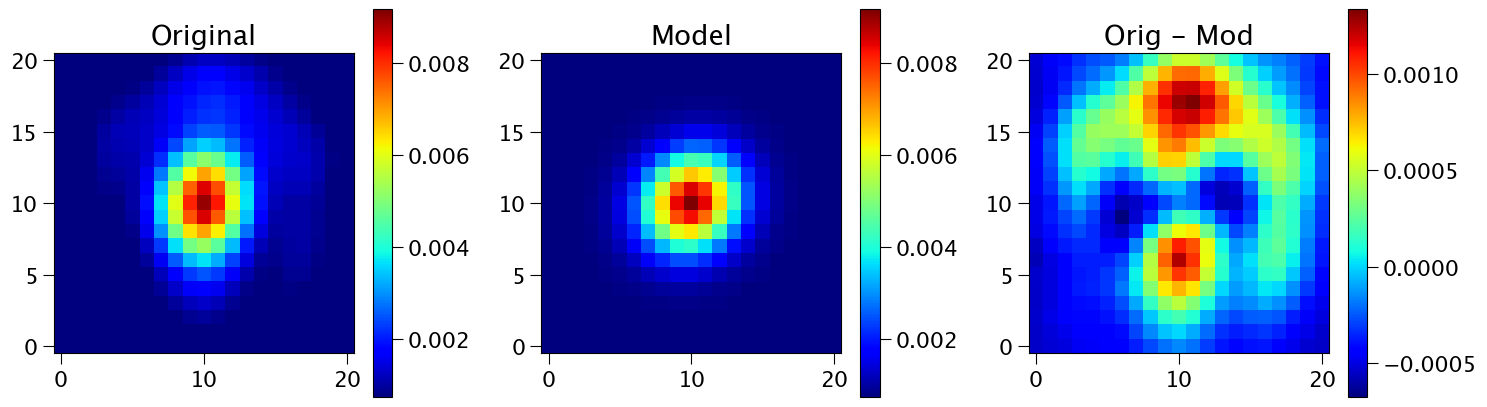

FWHM on iteration 1 = 53.39 mas | Empirical FWHM on iteration 1 = 62.5239307760551 mas
c0133_psf.fits 1 5.364616142419576 49.013386292027924 49.06623135075187 21.0
peak flux ratio =  0.009004967  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0133_psf.fits   0.245   401.1   53.39   49.5   49.5

c0133_psf.fits                   0.245   401.1   53.39  57147.4487

box size going into fit_gaussian2d() : 21.0


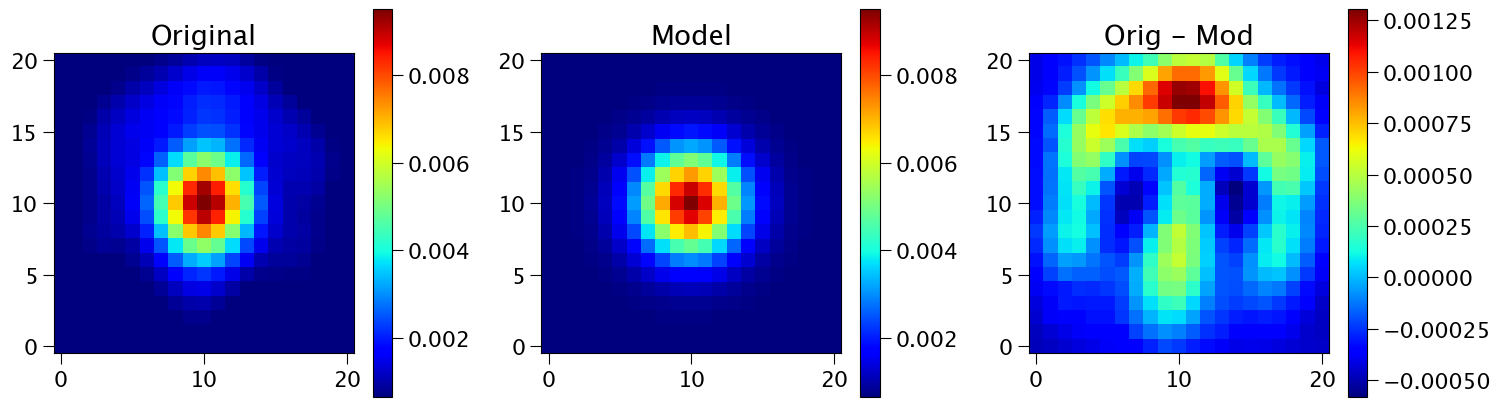

FWHM on iteration 1 = 58.56 mas | Empirical FWHM on iteration 1 = 59.421613790989255 mas
c0136_psf.fits 1 5.88414728689968 48.98845950239341 49.077938767437196 21.0
peak flux ratio =  0.009783294  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015may/clean/kp/c0136_psf.fits   0.266   389.1   58.56   49.5   49.5

c0136_psf.fits                   0.266   389.1   58.56  57147.4513

box size going into fit_gaussian2d() : 21.0


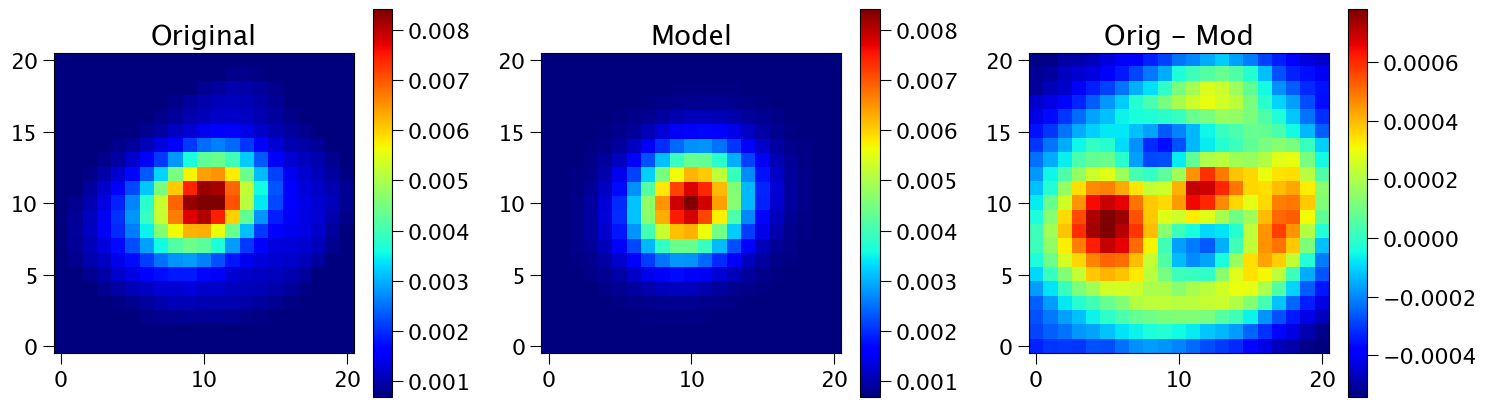

FWHM on iteration 1 = 60.04 mas | Empirical FWHM on iteration 1 = 61.50721373655653 mas
c0014_psf.fits 1 6.033008217543963 48.9715147682184 48.9877691520924 21.0
peak flux ratio =  0.008846528  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0014_psf.fits   0.241   403.6   60.04   49.5   49.5

c0014_psf.fits                   0.241   403.6   60.04  57114.3245

box size going into fit_gaussian2d() : 21.0


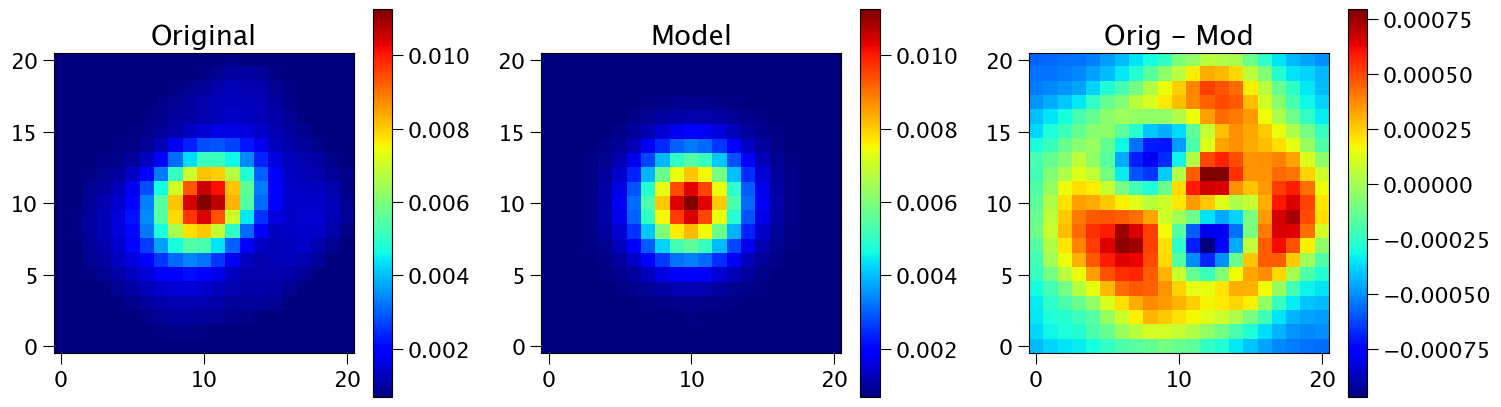

FWHM on iteration 1 = 55.58 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0017_psf.fits 1 5.584334072907528 48.99180448910022 48.97573049843237 21.0
peak flux ratio =  0.011444841  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0017_psf.fits   0.311   365.3   55.58   49.5   49.5

c0017_psf.fits                   0.311   365.3   55.58  57114.3276

box size going into fit_gaussian2d() : 21.0


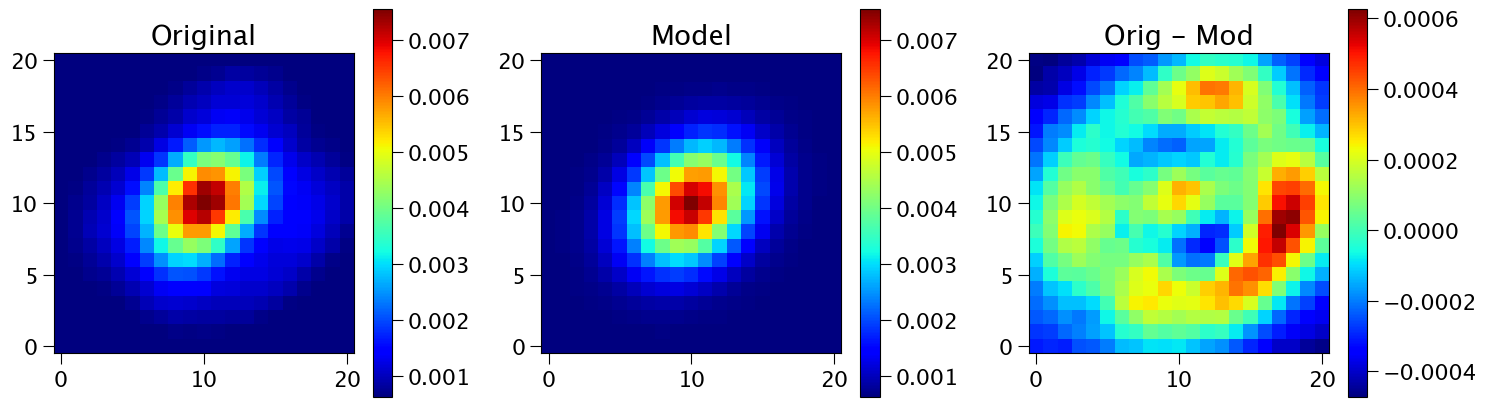

FWHM on iteration 1 = 63.46 mas | Empirical FWHM on iteration 1 = 66.43538388469548 mas
c0020_psf.fits 1 6.376238629352769 49.03977088104324 48.96837321295753 21.0
peak flux ratio =  0.007825138  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0020_psf.fits   0.213   420.6   63.46   49.5   49.5

c0020_psf.fits                   0.213   420.6   63.46  57114.3307

box size going into fit_gaussian2d() : 21.0


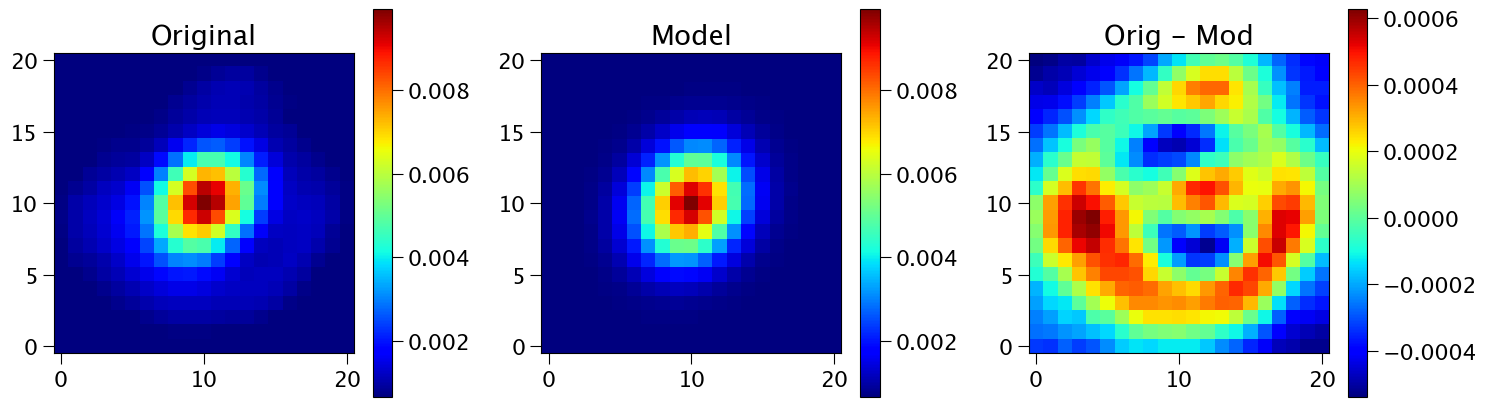

FWHM on iteration 1 = 56.51 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0023_psf.fits 1 5.677842799254447 48.99732338794328 48.96857090464084 21.0
peak flux ratio =  0.0102183  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0023_psf.fits   0.278   382.7   56.51   49.5   49.5

c0023_psf.fits                   0.278   382.7   56.51  57114.3337

box size going into fit_gaussian2d() : 21.0


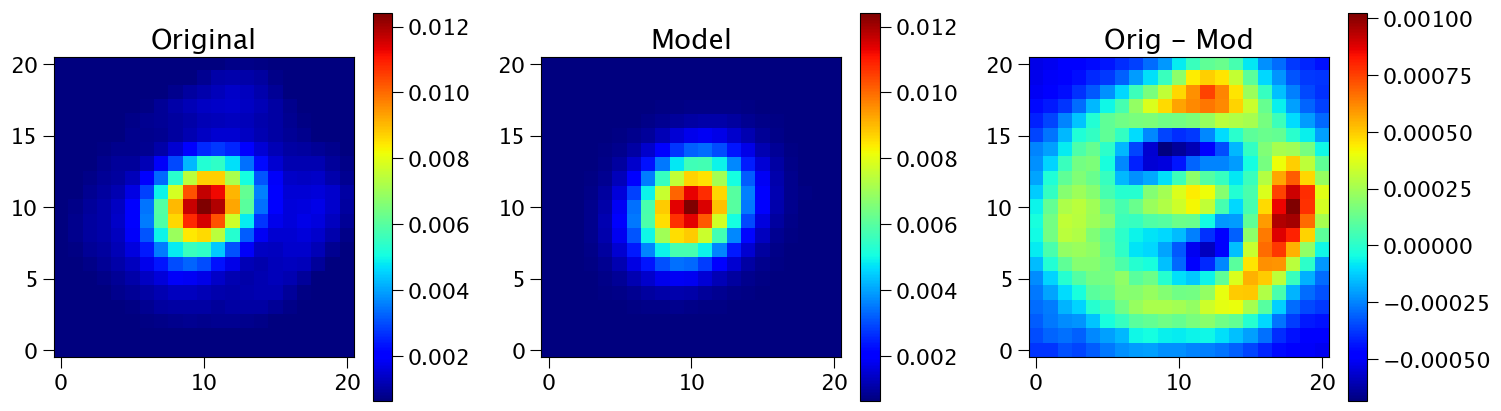

FWHM on iteration 1 = 55.50 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0026_psf.fits 1 5.576883718669018 49.023875086621416 48.98897157505656 21.0
peak flux ratio =  0.012731026  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0026_psf.fits   0.346   348.3   55.50   49.5   49.5

c0026_psf.fits                   0.346   348.3   55.50  57114.3368

box size going into fit_gaussian2d() : 21.0


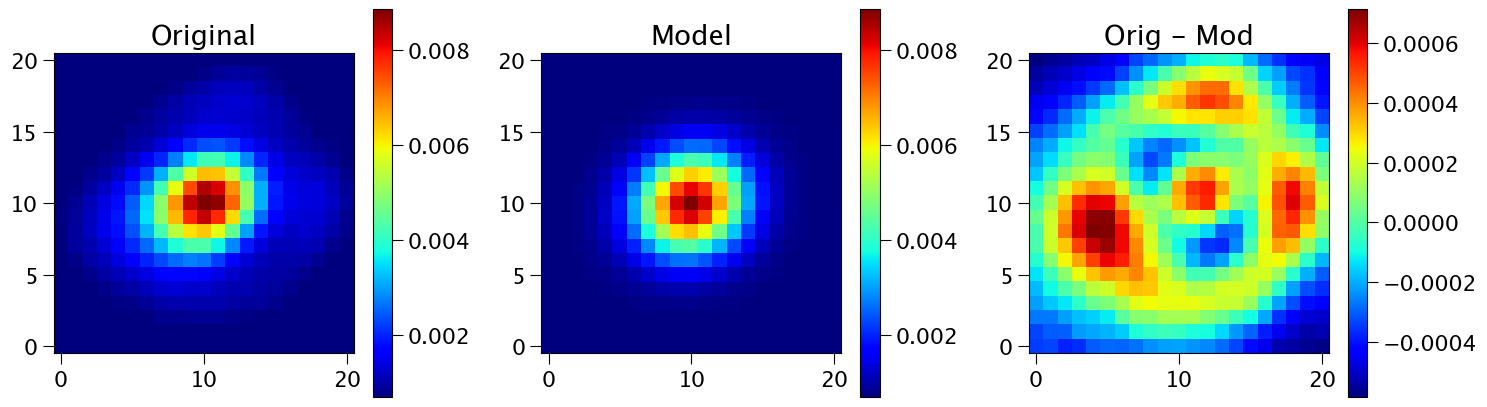

FWHM on iteration 1 = 57.62 mas | Empirical FWHM on iteration 1 = 58.350866381494306 mas
c0029_psf.fits 1 5.790207804788932 48.99892856449748 48.97179012059059 21.0
peak flux ratio =  0.00917459  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0029_psf.fits   0.249   398.4   57.62   49.5   49.5

c0029_psf.fits                   0.249   398.4   57.62  57114.3399

box size going into fit_gaussian2d() : 21.0


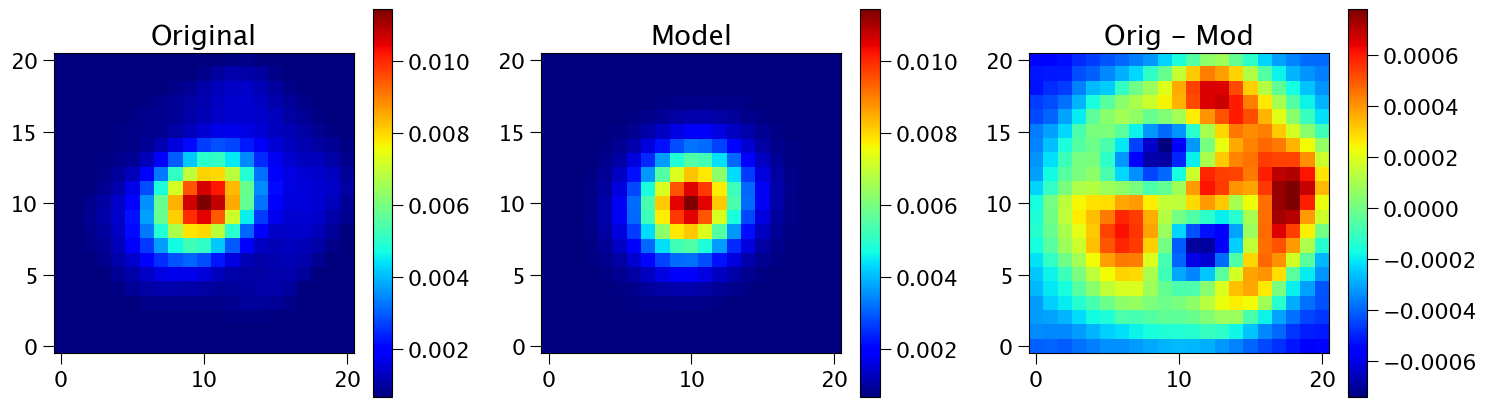

FWHM on iteration 1 = 55.29 mas | Empirical FWHM on iteration 1 = 55.0137244086197 mas
c0032_psf.fits 1 5.555337697276275 48.99856970060745 49.002589073381 21.0
peak flux ratio =  0.011580407  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0032_psf.fits   0.315   363.5   55.29   49.5   49.5

c0032_psf.fits                   0.315   363.5   55.29  57114.3446

box size going into fit_gaussian2d() : 21.0


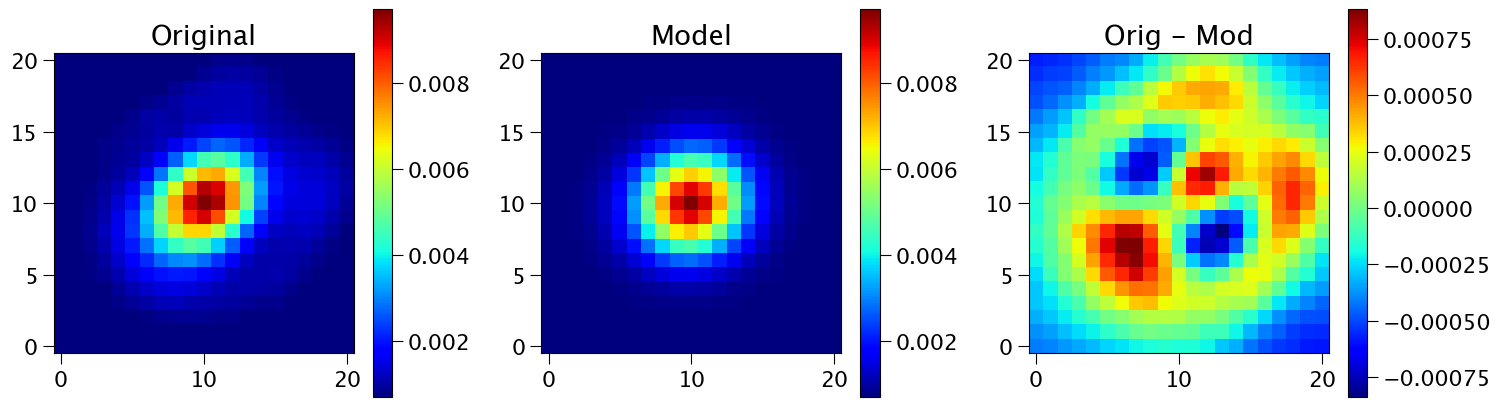

FWHM on iteration 1 = 56.73 mas | Empirical FWHM on iteration 1 = 58.350866381494306 mas
c0035_psf.fits 1 5.700739784383059 48.994234168822466 48.99500436677302 21.0
peak flux ratio =  0.009920188  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0035_psf.fits   0.270   387.1   56.73   49.5   49.5

c0035_psf.fits                   0.270   387.1   56.73  57114.3476

box size going into fit_gaussian2d() : 21.0


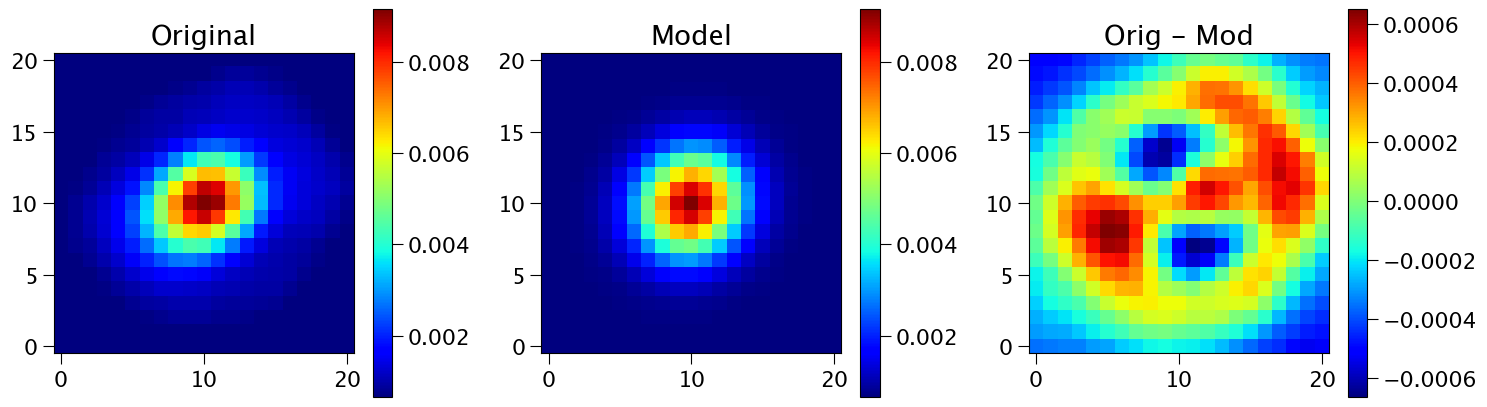

FWHM on iteration 1 = 58.61 mas | Empirical FWHM on iteration 1 = 58.350866381494306 mas
c0038_psf.fits 1 5.889004224674739 48.97939329199819 48.980448012555506 21.0
peak flux ratio =  0.009446441  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0038_psf.fits   0.257   394.2   58.61   49.5   49.5

c0038_psf.fits                   0.257   394.2   58.61  57114.3507

box size going into fit_gaussian2d() : 21.0


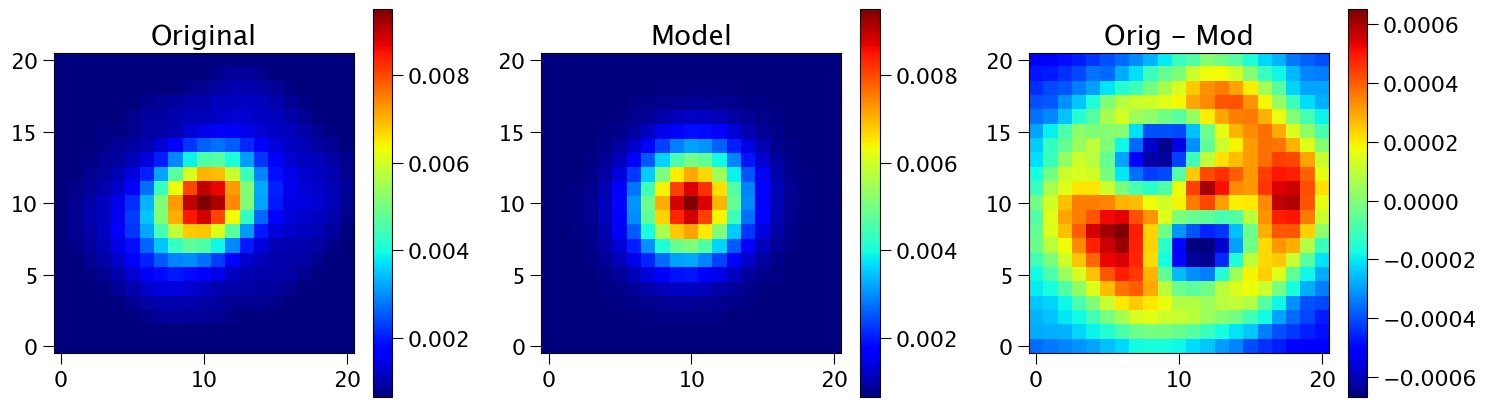

FWHM on iteration 1 = 58.67 mas | Empirical FWHM on iteration 1 = 58.350866381494306 mas
c0041_psf.fits 1 5.895062923580859 48.98029638653357 48.97398729625861 21.0
peak flux ratio =  0.009675893  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0041_psf.fits   0.263   390.7   58.67   49.5   49.5

c0041_psf.fits                   0.263   390.7   58.67  57114.3537

box size going into fit_gaussian2d() : 21.0


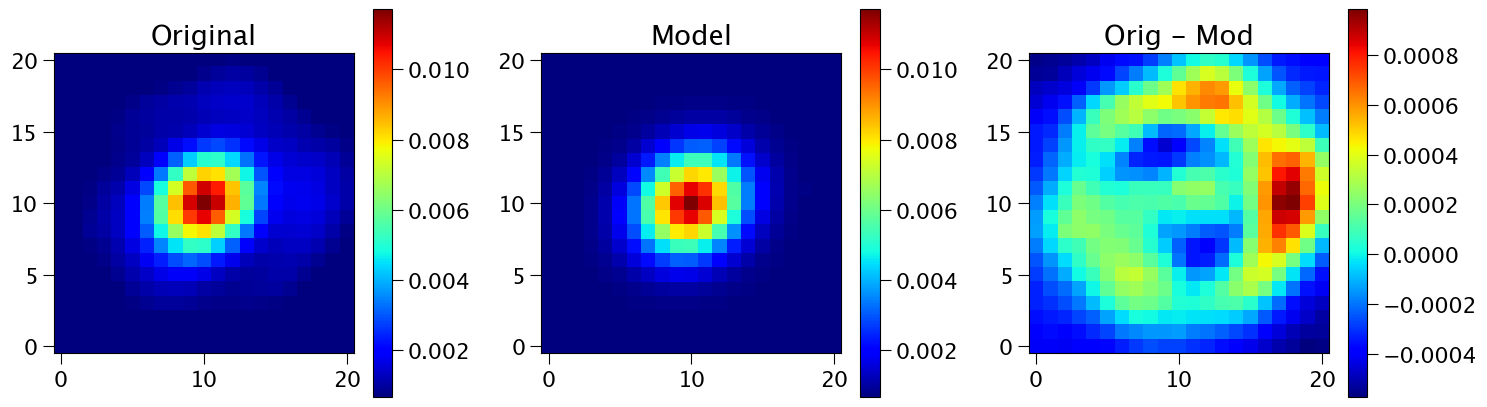

FWHM on iteration 1 = 55.12 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0044_psf.fits 1 5.538942766466588 49.0215208628946 49.00258881642991 21.0
peak flux ratio =  0.01181392  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0044_psf.fits   0.321   360.3   55.12   49.5   49.5

c0044_psf.fits                   0.321   360.3   55.12  57114.3567

box size going into fit_gaussian2d() : 21.0


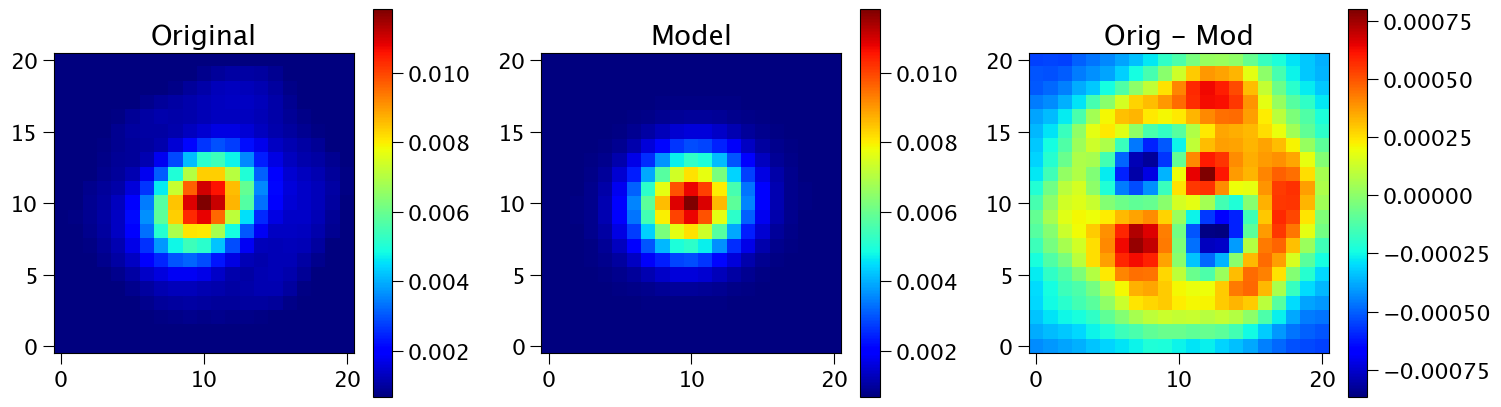

FWHM on iteration 1 = 54.59 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0047_psf.fits 1 5.485350484757696 49.00457794795709 49.004683308489085 21.0
peak flux ratio =  0.011971803  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0047_psf.fits   0.326   358.2   54.59   49.5   49.5

c0047_psf.fits                   0.326   358.2   54.59  57114.3601

box size going into fit_gaussian2d() : 21.0


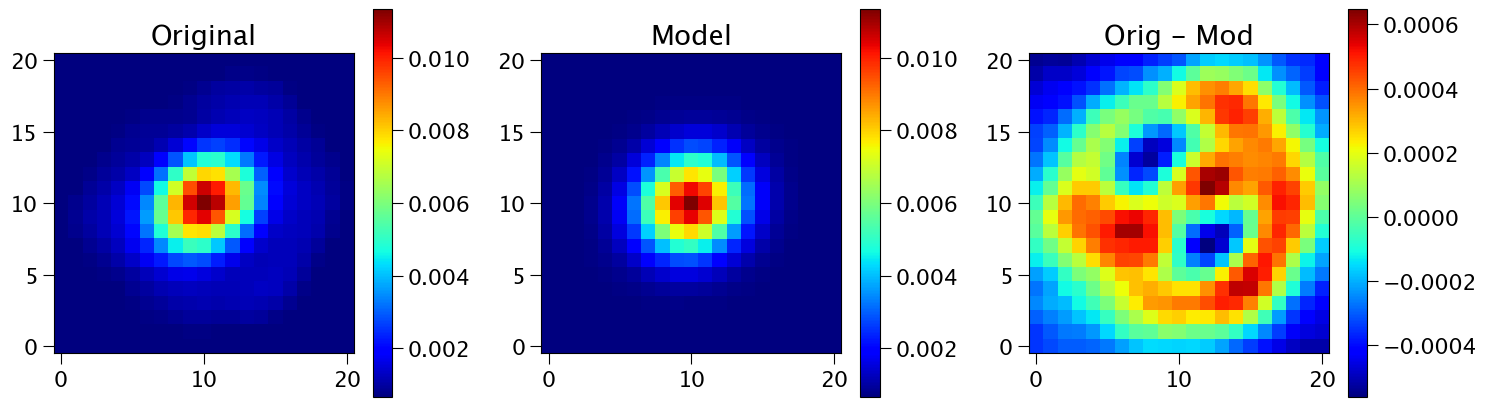

FWHM on iteration 1 = 54.15 mas | Empirical FWHM on iteration 1 = 55.0137244086197 mas
c0050_psf.fits 1 5.440690651626943 49.00654814587801 48.98290142014796 21.0
peak flux ratio =  0.011507467  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0050_psf.fits   0.313   364.5   54.15   49.5   49.5

c0050_psf.fits                   0.313   364.5   54.15  57114.3632

box size going into fit_gaussian2d() : 21.0


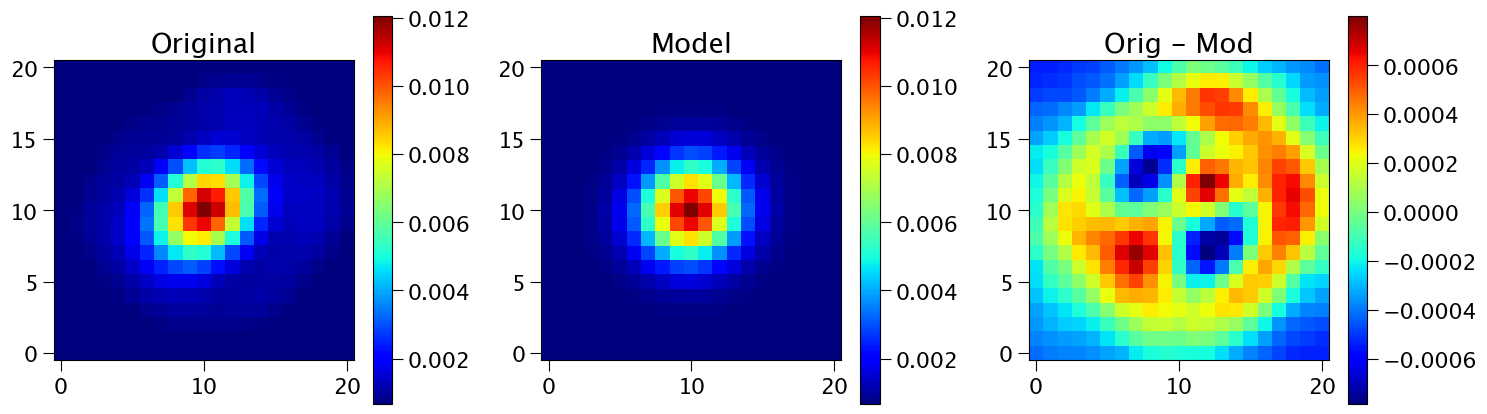

FWHM on iteration 1 = 53.54 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0053_psf.fits 1 5.380059835922376 49.00181061231646 48.99928213530313 21.0
peak flux ratio =  0.012191836  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0053_psf.fits   0.331   355.3   53.54   49.5   49.5

c0053_psf.fits                   0.331   355.3   53.54  57114.3662

box size going into fit_gaussian2d() : 21.0


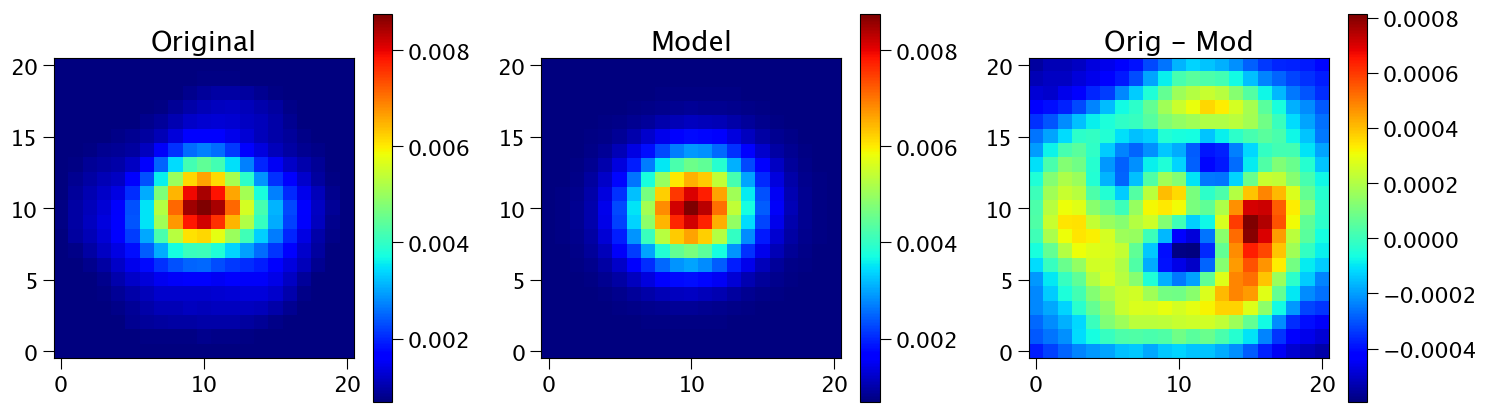

FWHM on iteration 1 = 62.38 mas | Empirical FWHM on iteration 1 = 62.5239307760551 mas
c0056_psf.fits 1 6.268151188133622 49.07674422801707 48.97201172583478 21.0
peak flux ratio =  0.009050107  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0056_psf.fits   0.246   400.4   62.38   49.5   49.5

c0056_psf.fits                   0.246   400.4   62.38  57114.3693

box size going into fit_gaussian2d() : 21.0


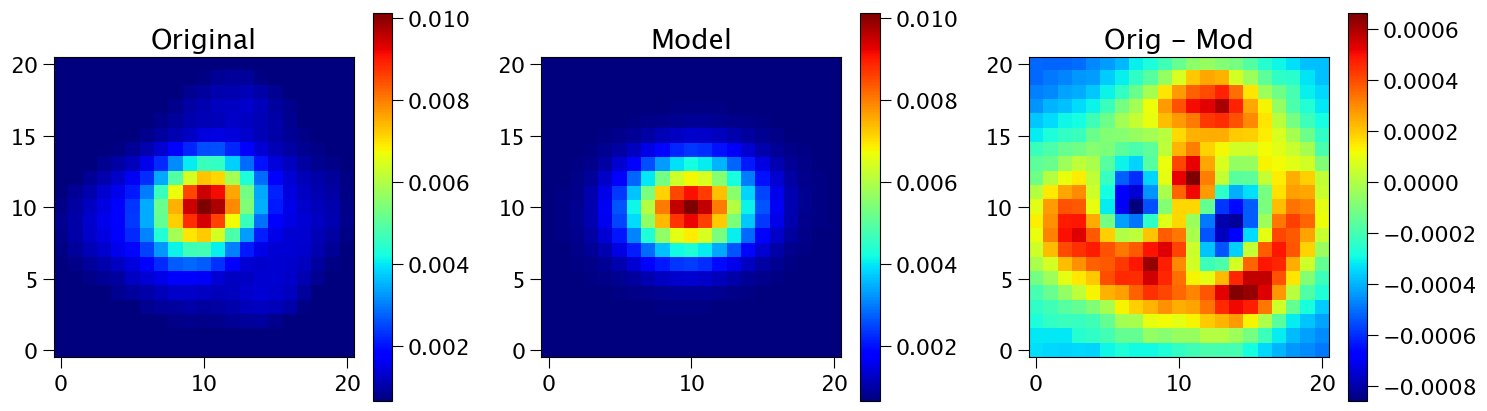

FWHM on iteration 1 = 58.44 mas | Empirical FWHM on iteration 1 = 57.26009980271185 mas
c0059_psf.fits 1 5.87212106440069 48.99553057434862 48.974788597317485 21.0
peak flux ratio =  0.010285478  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0059_psf.fits   0.280   381.7   58.44   49.5   49.5

c0059_psf.fits                   0.280   381.7   58.44  57114.3735

box size going into fit_gaussian2d() : 21.0


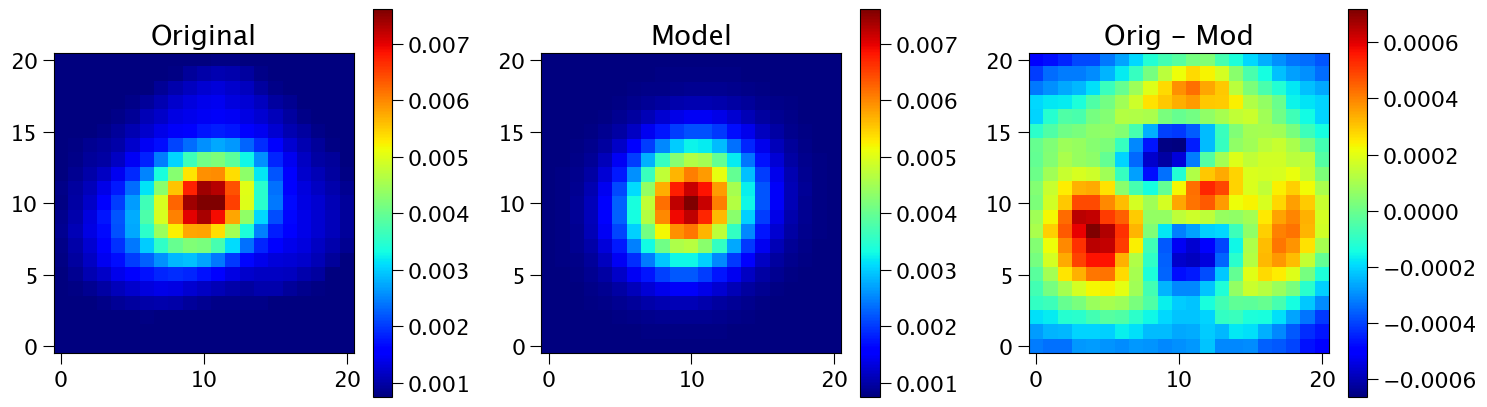

FWHM on iteration 1 = 66.81 mas | Empirical FWHM on iteration 1 = 69.22408515878199 mas
c0062_psf.fits 1 6.713059216583898 23.957768852804847 23.976620009018504 21.0
peak flux ratio =  0.007956182  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0062_psf.fits   0.216   418.4   66.81   24.5   24.5

c0062_psf.fits                   0.216   418.4   66.81  57114.3868

box size going into fit_gaussian2d() : 21.0


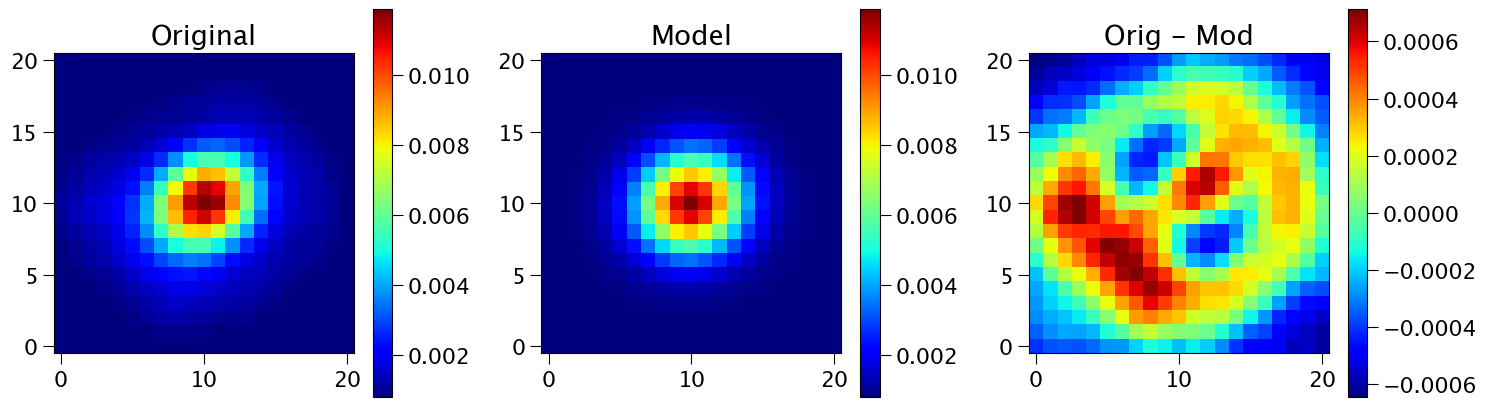

FWHM on iteration 1 = 57.20 mas | Empirical FWHM on iteration 1 = 58.350866381494306 mas
c0065_psf.fits 1 5.74778755039703 24.005428030790835 24.00166974947839 21.0
peak flux ratio =  0.012249856  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0065_psf.fits   0.333   354.5   57.20   24.5   24.5

c0065_psf.fits                   0.333   354.5   57.20  57114.3894

box size going into fit_gaussian2d() : 21.0


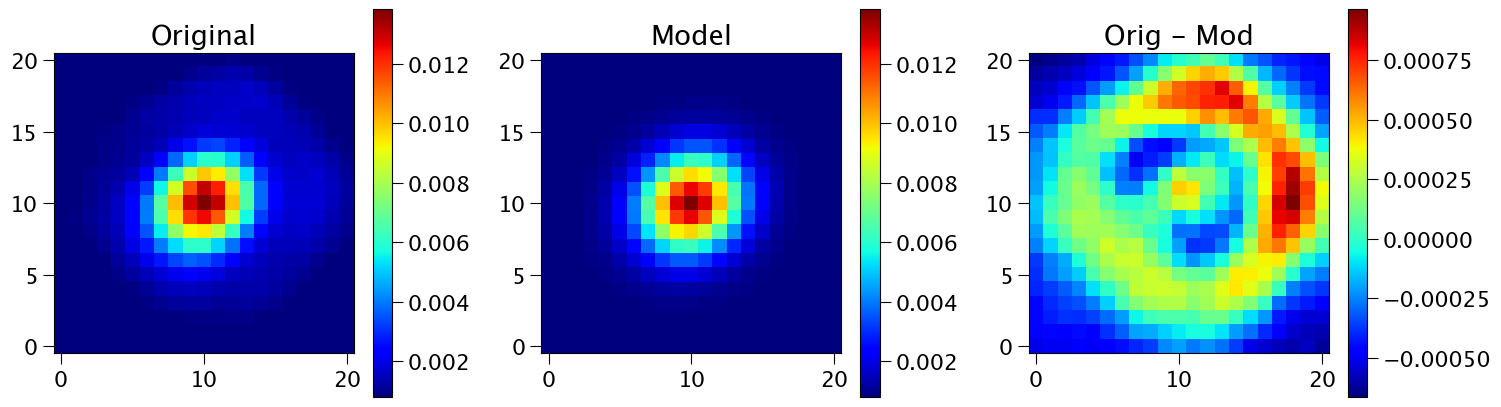

FWHM on iteration 1 = 54.84 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0068_psf.fits 1 5.510560620934642 23.997022186258533 23.986068625246055 21.0
peak flux ratio =  0.014142796  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0068_psf.fits   0.385   330.6   54.84   24.5   24.5

c0068_psf.fits                   0.385   330.6   54.84  57114.3920

box size going into fit_gaussian2d() : 21.0


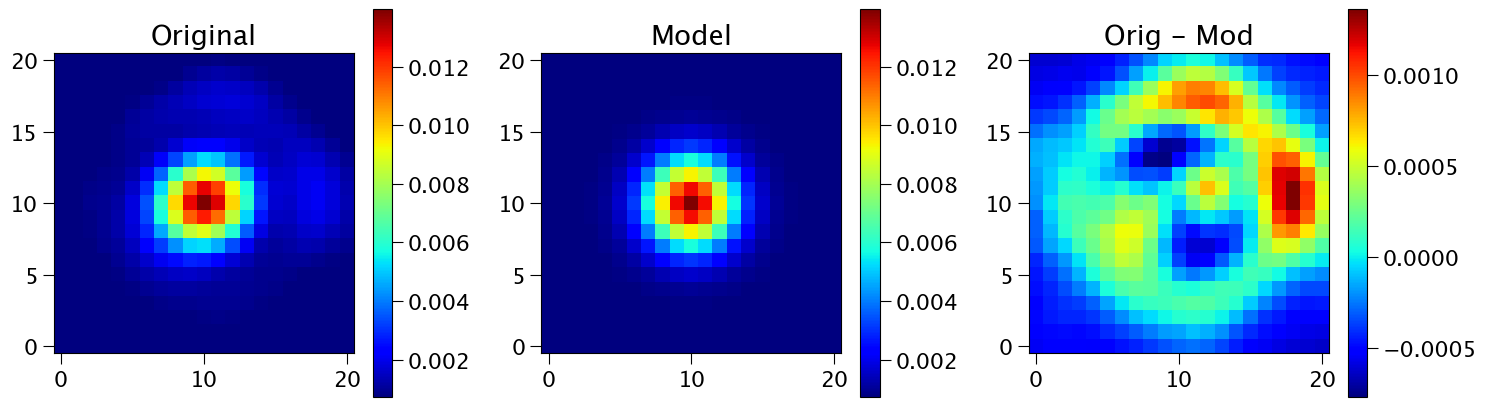

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0071_psf.fits 1 5.082730439442657 48.991696291613785 49.00168154837103 21.0
peak flux ratio =  0.013903556  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0071_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0071_psf.fits                  -1.000    -1.0   -1.00  57114.3970

box size going into fit_gaussian2d() : 21.0


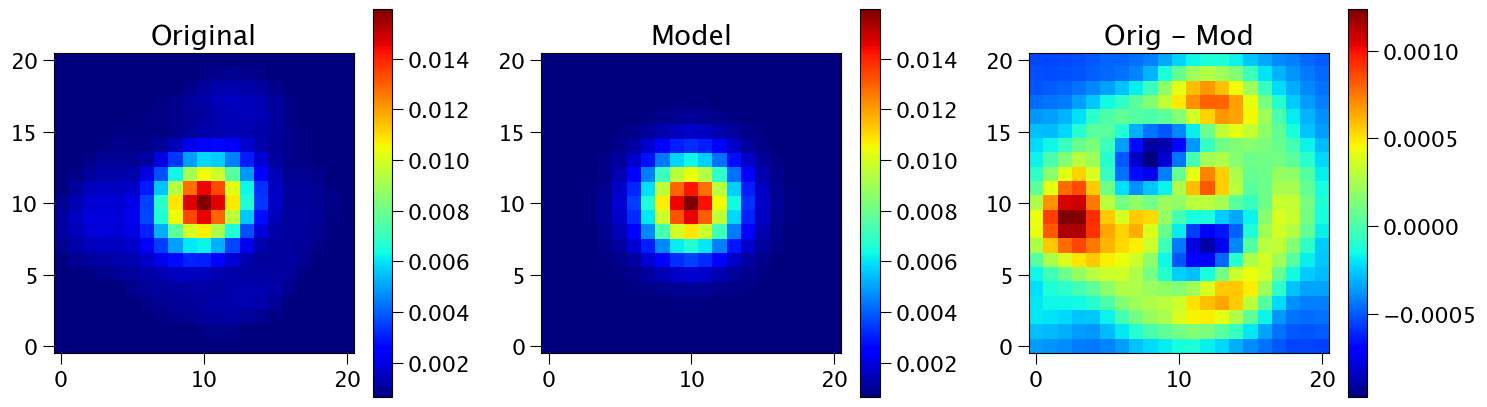

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0074_psf.fits 1 5.082730439442657 48.97165305009018 48.94625260381882 21.0
peak flux ratio =  0.016136328  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0074_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0074_psf.fits                  -1.000    -1.0   -1.00  57114.3995

box size going into fit_gaussian2d() : 21.0


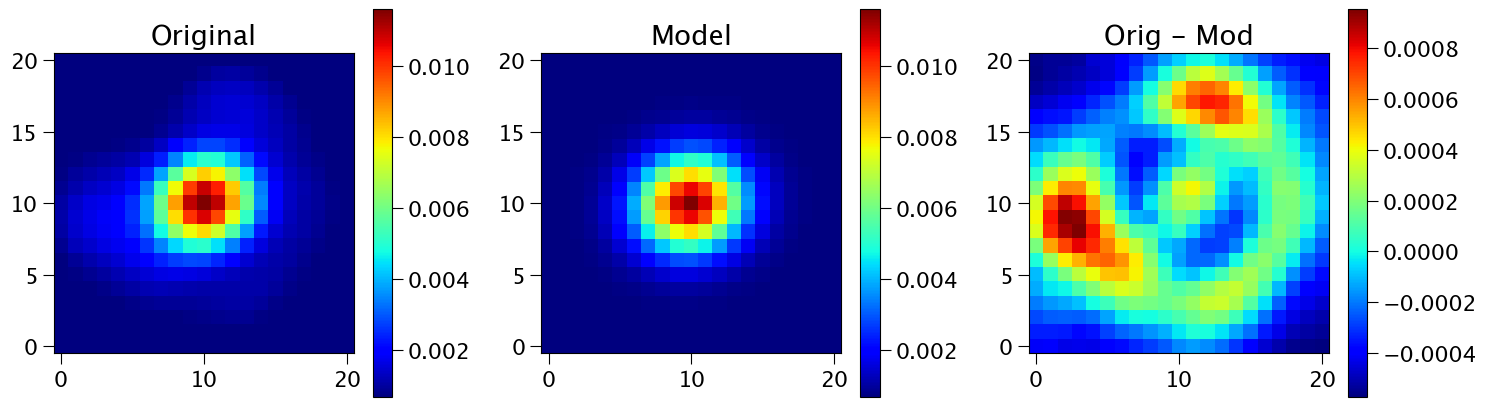

FWHM on iteration 1 = 56.07 mas | Empirical FWHM on iteration 1 = 55.0137244086197 mas
c0077_psf.fits 1 5.634275993853095 48.9515457605561 48.99601494312357 21.0
peak flux ratio =  0.011874121  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0077_psf.fits   0.323   359.5   56.07   49.5   49.5

c0077_psf.fits                   0.323   359.5   56.07  57114.4021

box size going into fit_gaussian2d() : 21.0


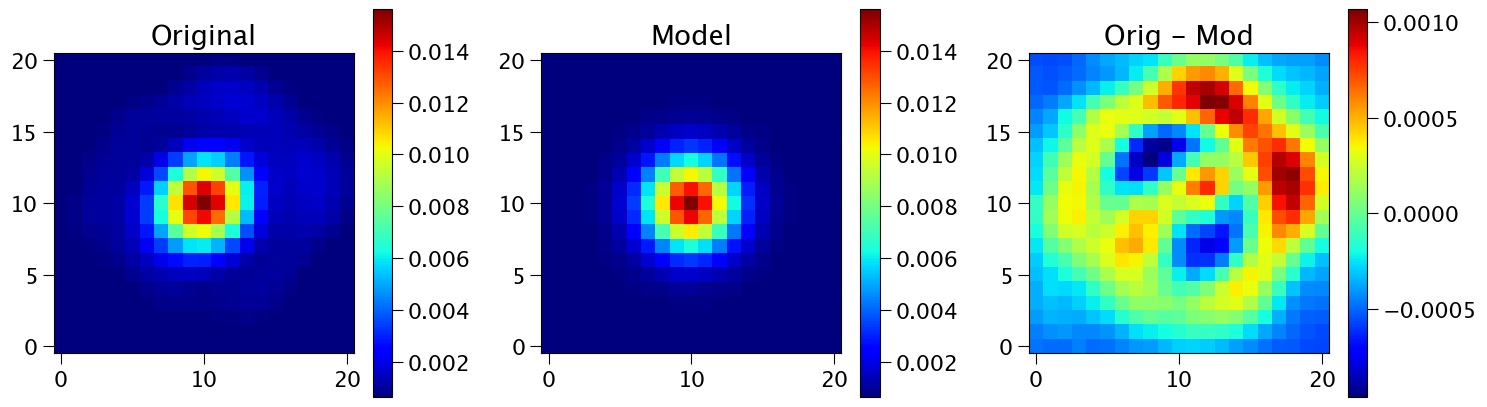

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0080_psf.fits 1 5.082730439442657 48.96460541463239 48.97827715557055 21.0
peak flux ratio =  0.01580797  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0080_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0080_psf.fits                  -1.000    -1.0   -1.00  57114.4050

box size going into fit_gaussian2d() : 21.0


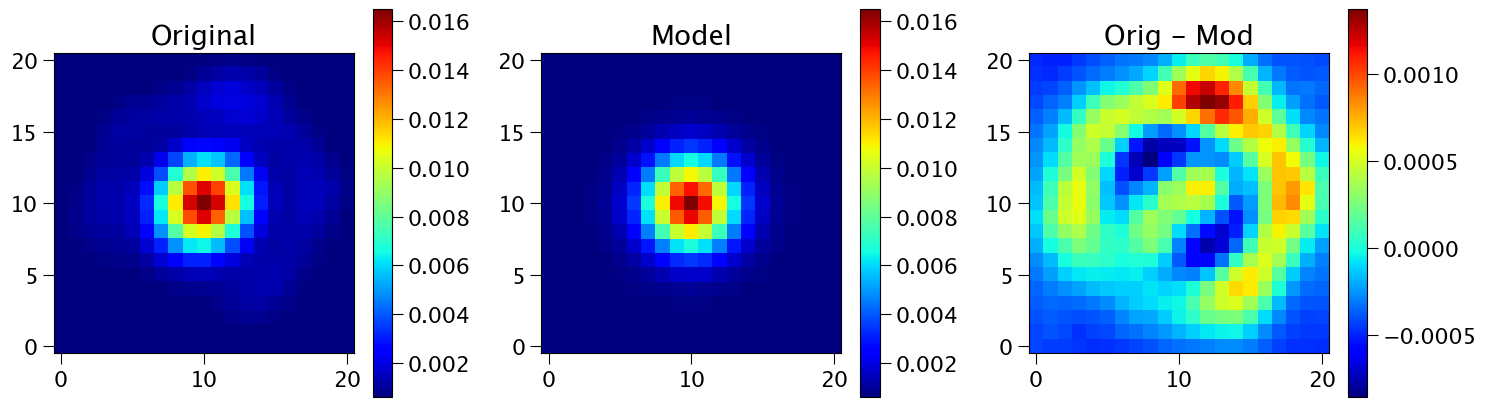

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0083_psf.fits 1 5.082730439442657 48.987815745273295 48.976884309638514 21.0
peak flux ratio =  0.01685811  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0083_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0083_psf.fits                  -1.000    -1.0   -1.00  57114.4076

box size going into fit_gaussian2d() : 21.0


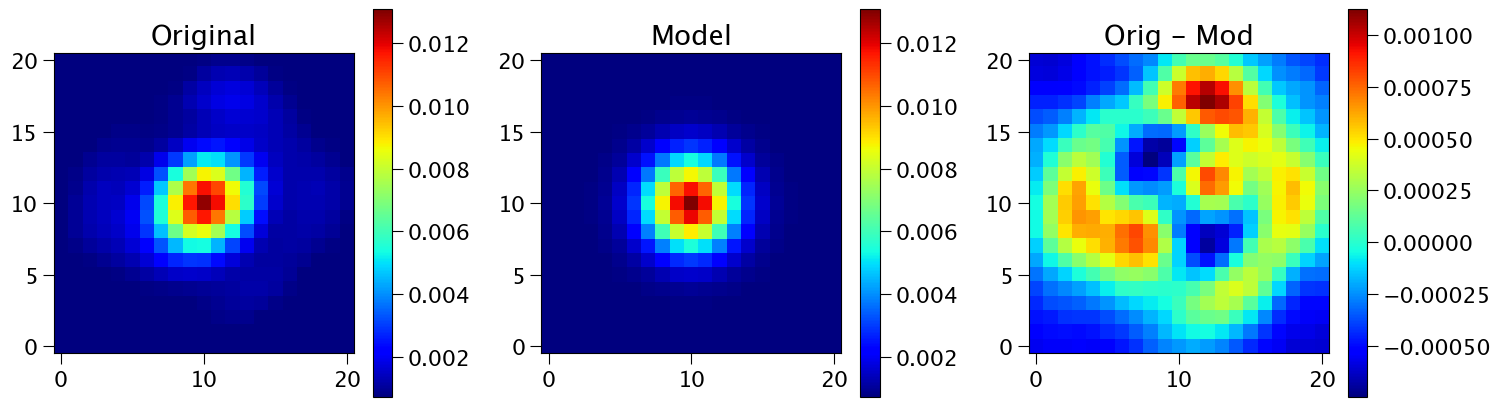

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0086_psf.fits 1 5.082730439442657 49.000721524282014 48.978138393392534 21.0
peak flux ratio =  0.012862568  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0086_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0086_psf.fits                  -1.000    -1.0   -1.00  57114.4102

box size going into fit_gaussian2d() : 21.0


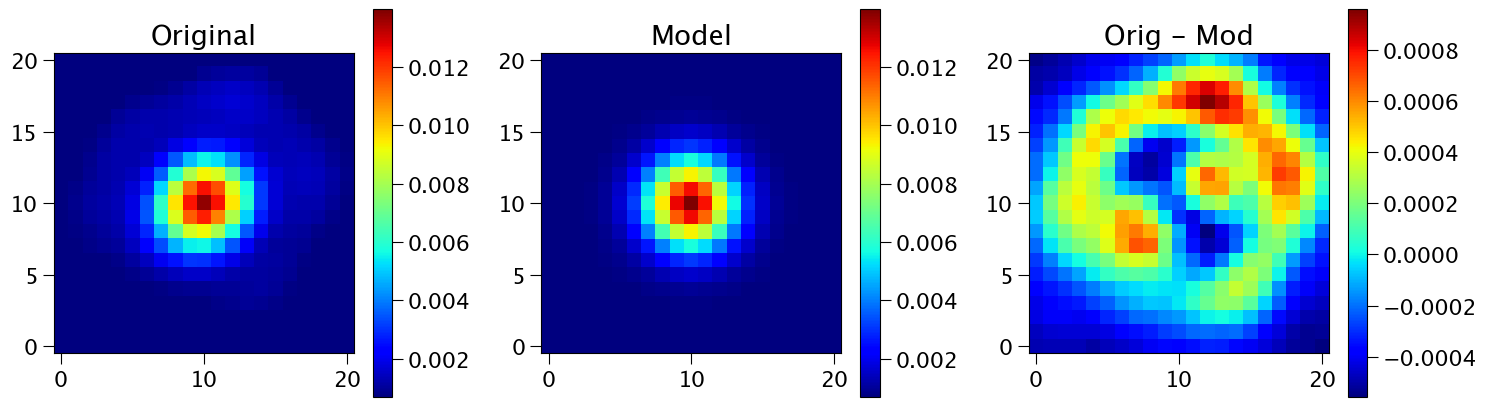

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0089_psf.fits 1 5.082730439442657 48.970250862664734 48.99607530515428 21.0
peak flux ratio =  0.013729435  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0089_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0089_psf.fits                  -1.000    -1.0   -1.00  57114.4130

box size going into fit_gaussian2d() : 21.0


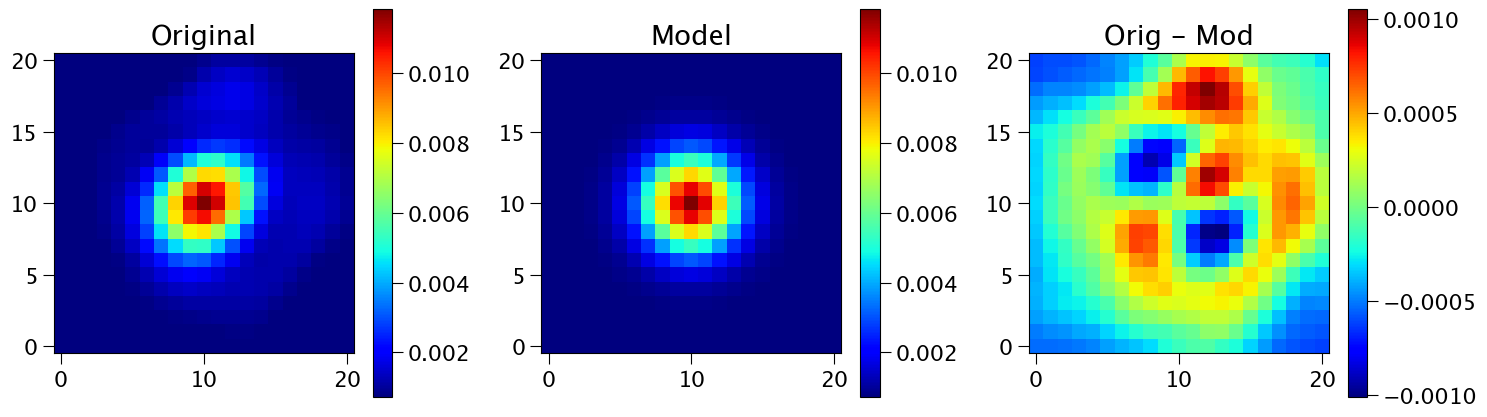

FWHM on iteration 1 = 53.33 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0092_psf.fits 1 5.358566837330625 49.01679516457689 49.008196992512445 21.0
peak flux ratio =  0.012014138  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0092_psf.fits   0.327   357.6   53.33   49.5   49.5

c0092_psf.fits                   0.327   357.6   53.33  57114.4156

box size going into fit_gaussian2d() : 21.0


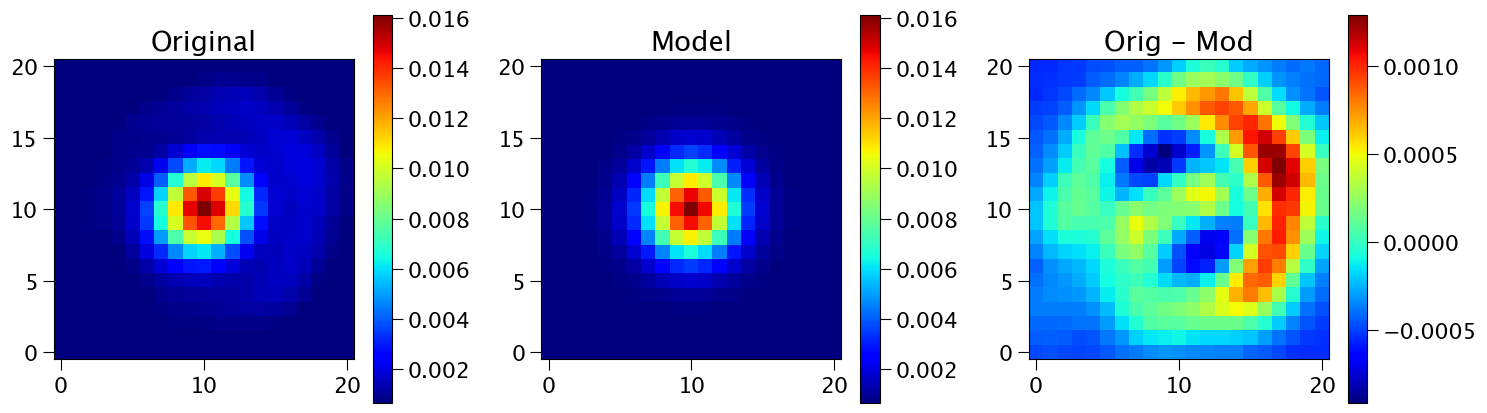

FWHM on iteration 1 = 50.98 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0095_psf.fits 1 5.1229150069339635 49.00962530783035 49.01263856531472 21.0
peak flux ratio =  0.016309222  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0095_psf.fits   0.443   304.9   50.98   49.5   49.5

c0095_psf.fits                   0.443   304.9   50.98  57114.4181

box size going into fit_gaussian2d() : 21.0


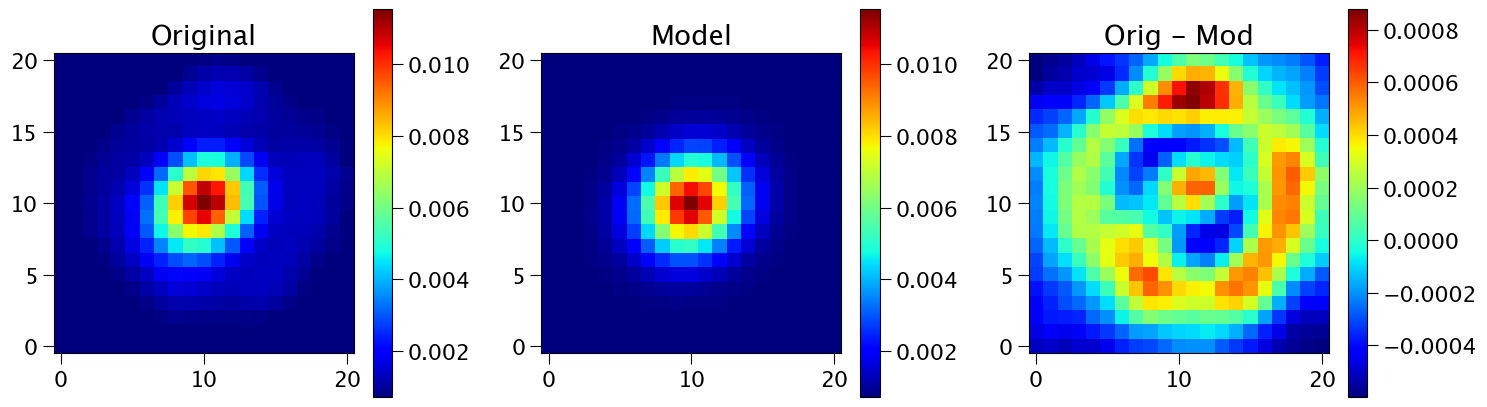

FWHM on iteration 1 = 53.64 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0098_psf.fits 1 5.389775322035434 48.98415889508921 48.95623424096665 21.0
peak flux ratio =  0.011757509  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0098_psf.fits   0.320   361.1   53.64   49.5   49.5

c0098_psf.fits                   0.320   361.1   53.64  57114.4210

box size going into fit_gaussian2d() : 21.0


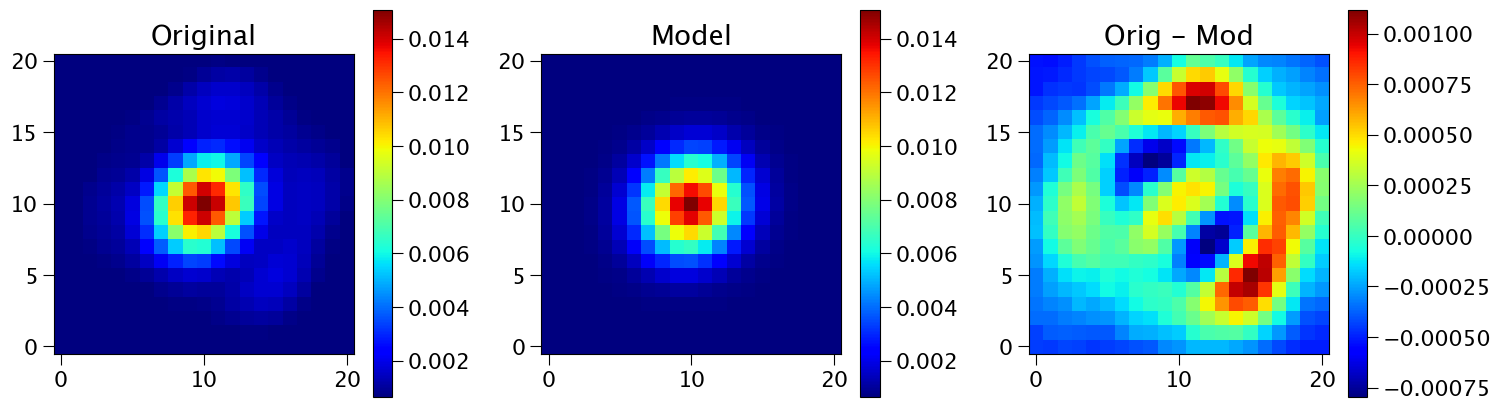

FWHM on iteration 1 = 52.96 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0101_psf.fits 1 5.32135928916902 49.00181366830497 48.96424833438524 21.0
peak flux ratio =  0.015545135  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0101_psf.fits   0.423   313.8   52.96   49.5   49.5

c0101_psf.fits                   0.423   313.8   52.96  57114.4236

box size going into fit_gaussian2d() : 21.0


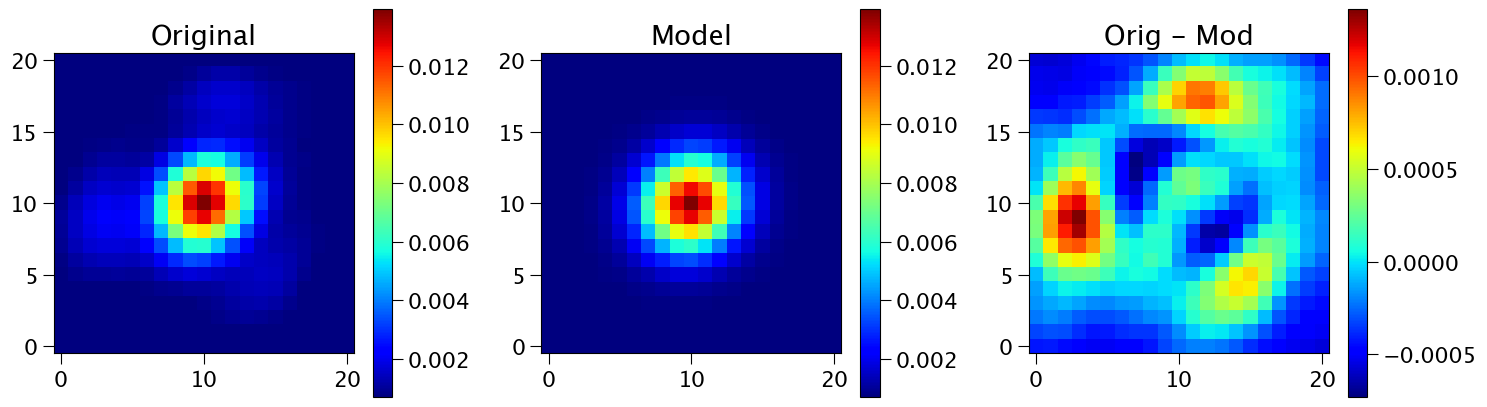

FWHM on iteration 1 = 52.79 mas | Empirical FWHM on iteration 1 = 53.85541101182941 mas
c0104_psf.fits 1 5.304852294742135 48.988881961913236 48.98079003757255 21.0
peak flux ratio =  0.014035412  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0104_psf.fits   0.382   331.9   52.79   49.5   49.5

c0104_psf.fits                   0.382   331.9   52.79  57114.4262

box size going into fit_gaussian2d() : 21.0


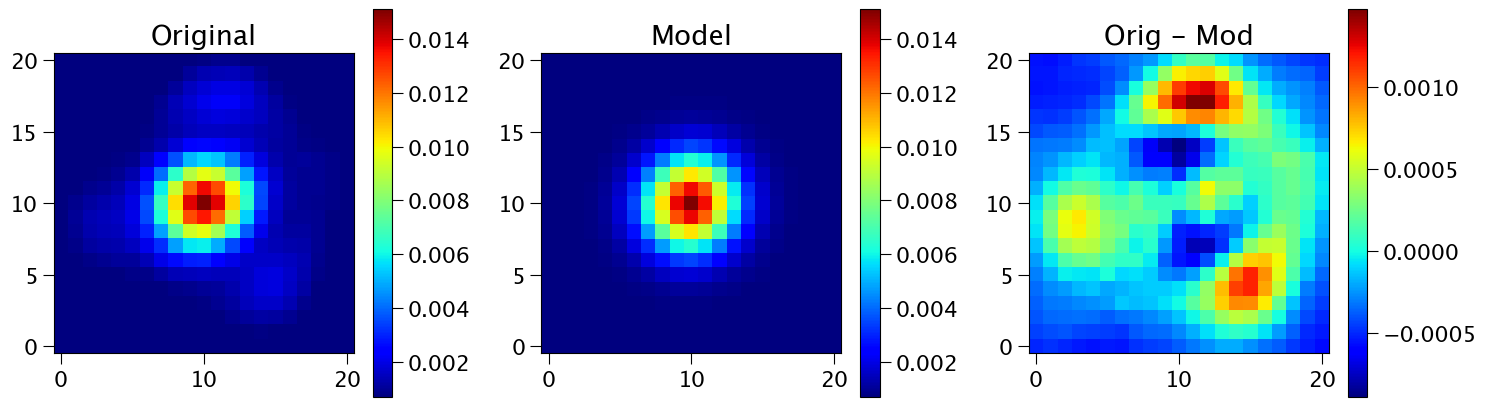

FWHM on iteration 1 = 51.61 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0107_psf.fits 1 5.185890305655944 48.98180139949342 48.99085760142555 21.0
peak flux ratio =  0.015197799  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0107_psf.fits   0.413   317.9   51.61   49.5   49.5

c0107_psf.fits                   0.413   317.9   51.61  57114.4295

box size going into fit_gaussian2d() : 21.0


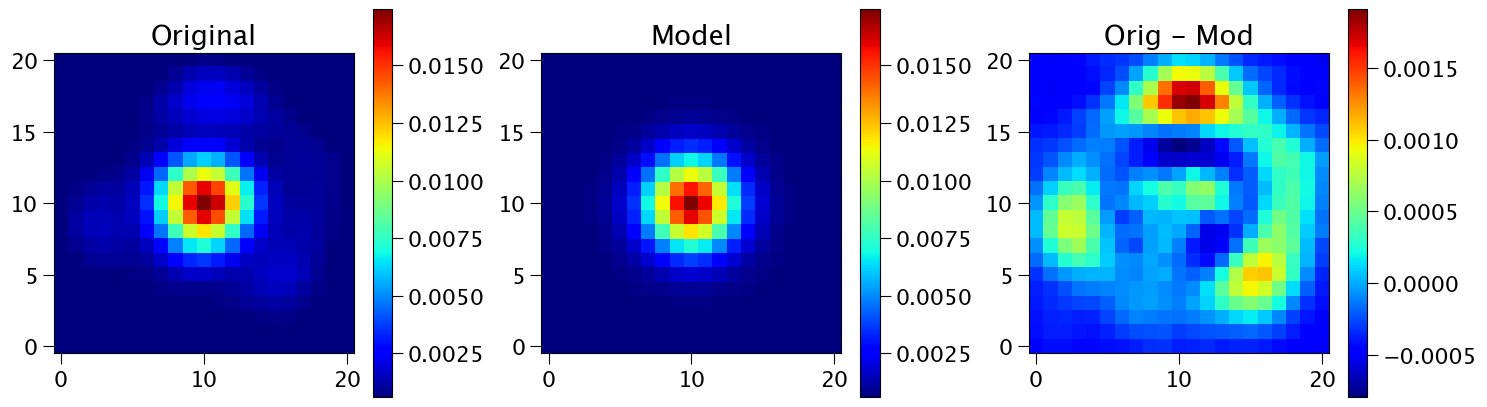

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0110_psf.fits 1 5.082730439442657 49.03504840082881 48.94876277972521 21.0
peak flux ratio =  0.01764552  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0110_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0110_psf.fits                  -1.000    -1.0   -1.00  57114.4321

box size going into fit_gaussian2d() : 21.0


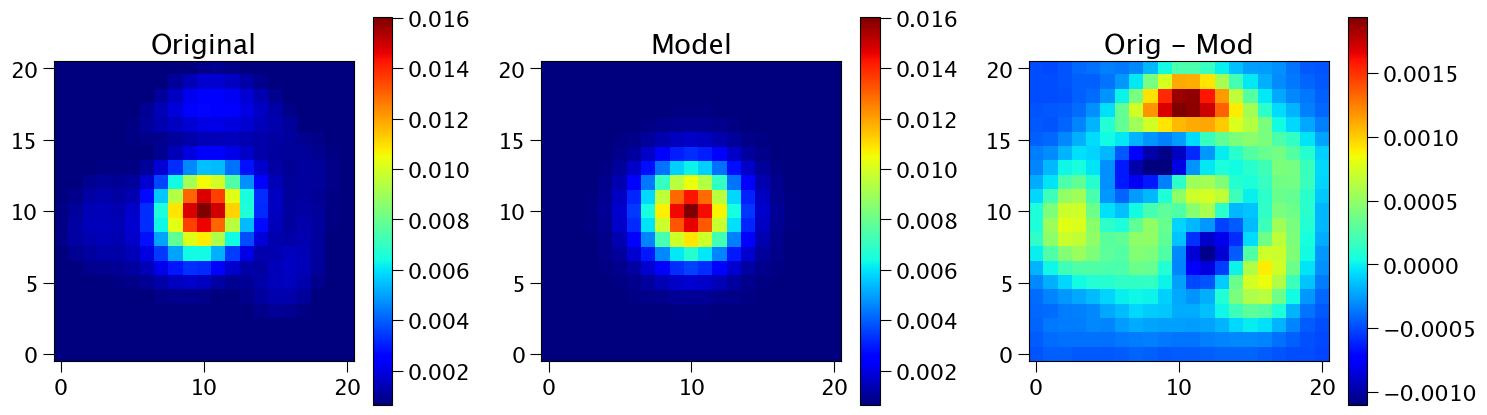

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0113_psf.fits 1 5.082730439442657 48.99204830251666 48.94264404347678 21.0
peak flux ratio =  0.016266726  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0113_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0113_psf.fits                  -1.000    -1.0   -1.00  57114.4347

box size going into fit_gaussian2d() : 21.0


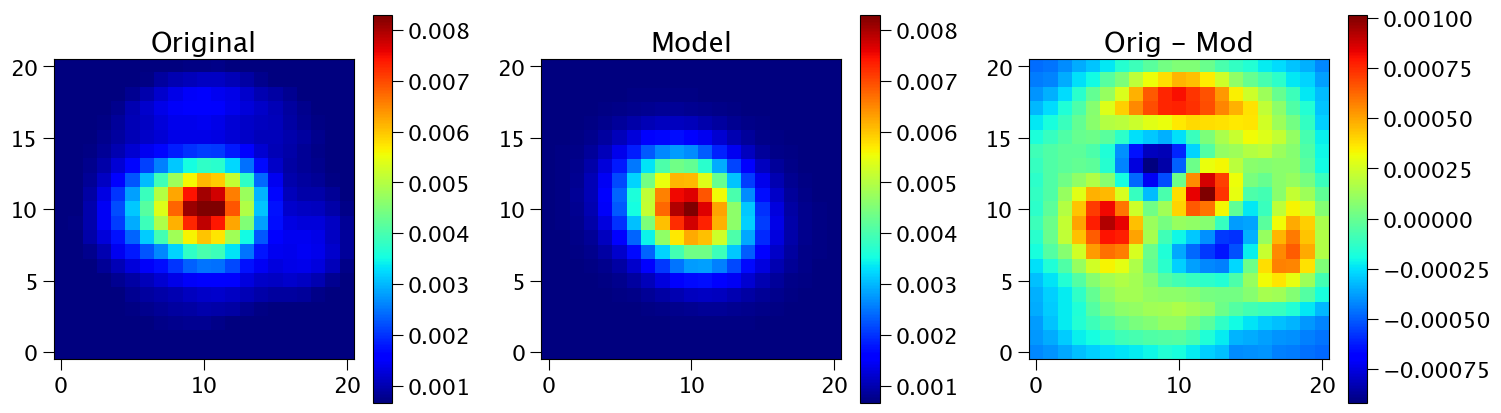

FWHM on iteration 1 = 62.07 mas | Empirical FWHM on iteration 1 = 62.5239307760551 mas
c0116_psf.fits 1 6.236818674755582 48.84803242600124 48.98800844372095 21.0
peak flux ratio =  0.008681549  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0116_psf.fits   0.236   406.3   62.07   49.5   49.5

c0116_psf.fits                   0.236   406.3   62.07  57114.4393

box size going into fit_gaussian2d() : 21.0


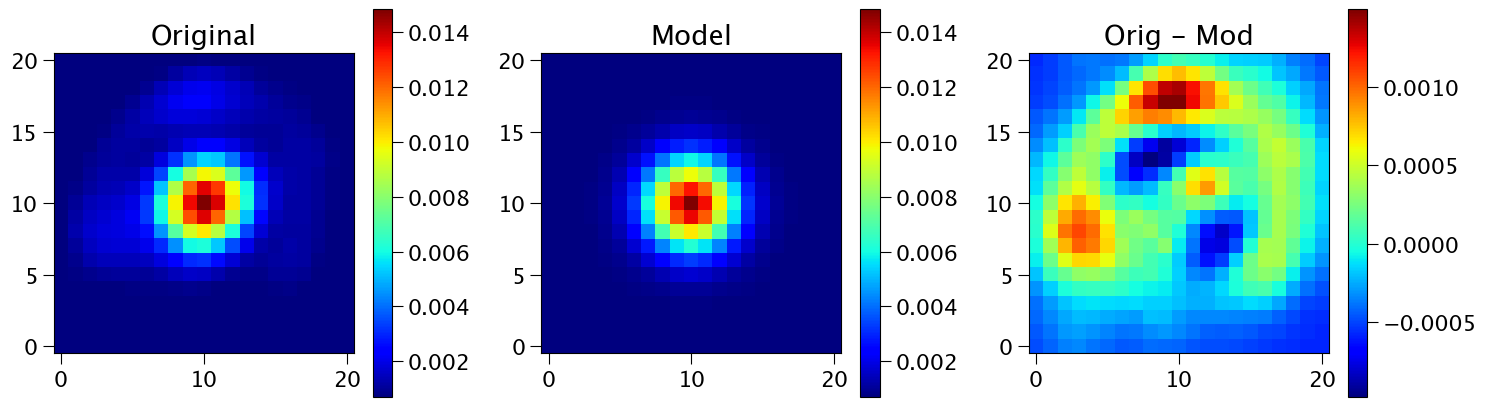

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0119_psf.fits 1 5.082730439442657 48.99671762202081 48.95867896570276 21.0
peak flux ratio =  0.01503182  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0119_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0119_psf.fits                  -1.000    -1.0   -1.00  57114.4419

box size going into fit_gaussian2d() : 21.0


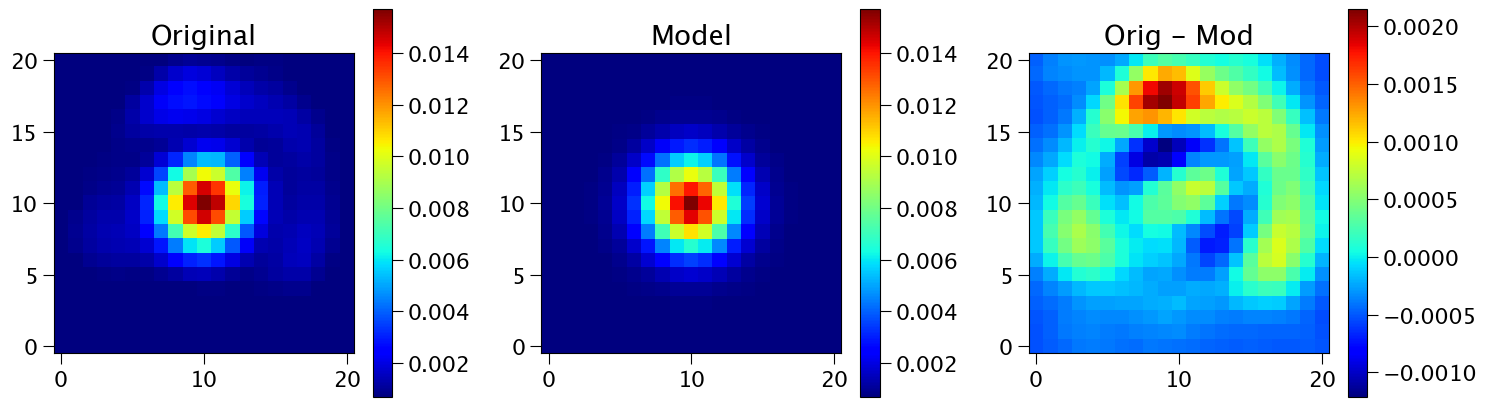

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0122_psf.fits 1 5.082730439442657 49.03413334525388 48.9378505788647 21.0
peak flux ratio =  0.016192036  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0122_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0122_psf.fits                  -1.000    -1.0   -1.00  57114.4444

box size going into fit_gaussian2d() : 21.0


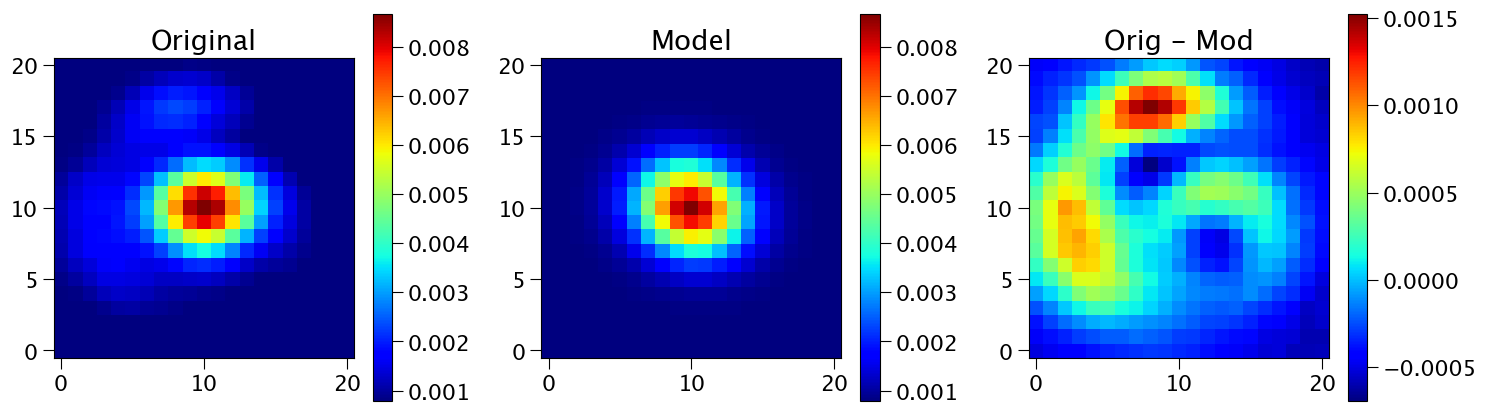

FWHM on iteration 1 = 55.91 mas | Empirical FWHM on iteration 1 = 57.26009980271185 mas
c0141_psf.fits 1 5.618449289139755 48.99169217595998 49.01022343404861 21.0
peak flux ratio =  0.008904536  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0141_psf.fits   0.242   402.7   55.91   49.5   49.5

c0141_psf.fits                   0.242   402.7   55.91  57114.4726

box size going into fit_gaussian2d() : 21.0


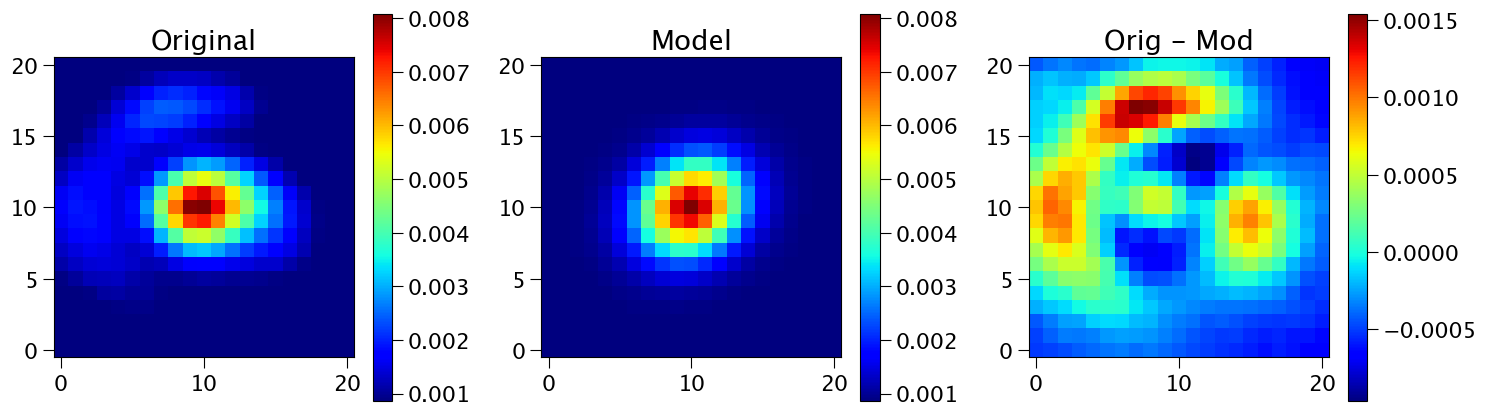

FWHM on iteration 1 = 55.64 mas | Empirical FWHM on iteration 1 = 58.350866381494306 mas
c0144_psf.fits 1 5.591059740558687 48.99929285730894 49.0208304882086 21.0
peak flux ratio =  0.008197011  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0144_psf.fits   0.223   414.3   55.64   49.5   49.5

c0144_psf.fits                   0.223   414.3   55.64  57114.4752

box size going into fit_gaussian2d() : 21.0


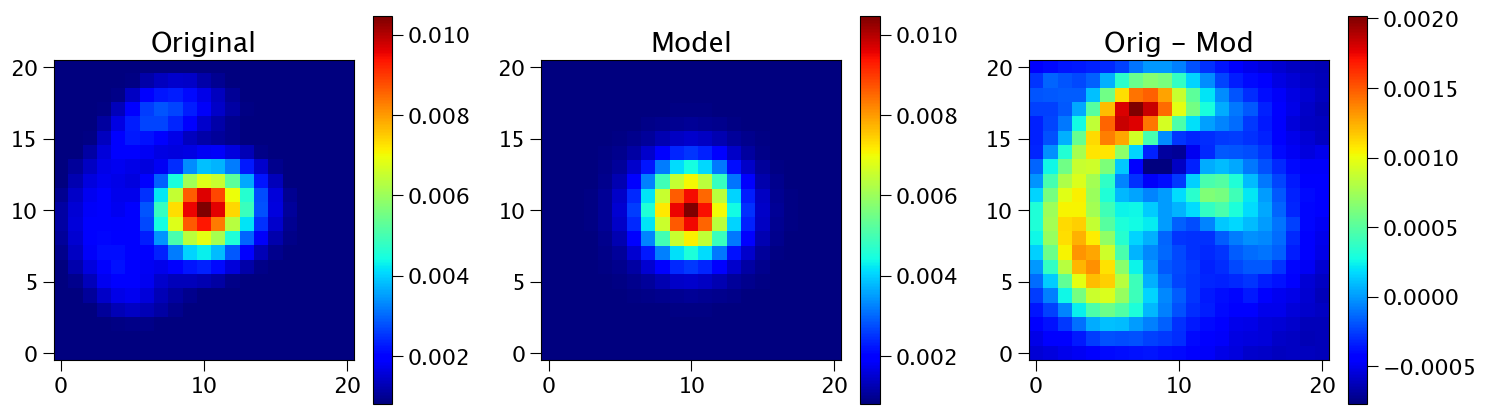

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 52.67163104744902 mas
c0147_psf.fits 1 5.082730439442657 48.96467888821937 48.98892644989624 21.0
peak flux ratio =  0.010524939  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0147_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0147_psf.fits                  -1.000    -1.0   -1.00  57114.4778

box size going into fit_gaussian2d() : 21.0


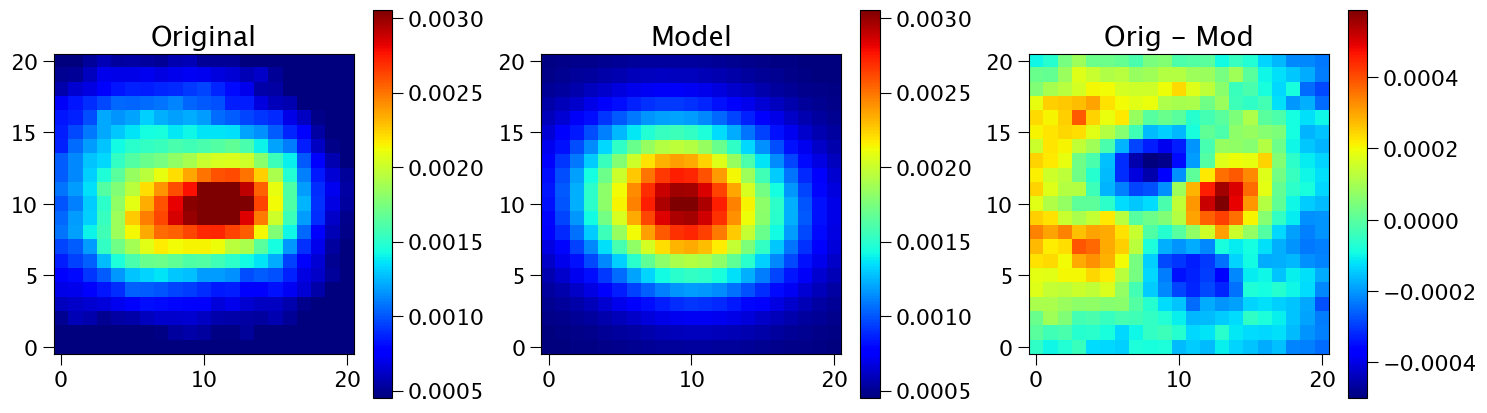

FWHM on iteration 1 = 100.84 mas | Empirical FWHM on iteration 1 = 103.53206814620742 mas
c0150_psf.fits 1 10.132728719831746 48.49570154293175 49.03615592753214 21.0
peak flux ratio =  0.0032575335  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0150_psf.fits   0.089   526.4  100.84   49.5   49.5

c0150_psf.fits                   0.089   526.4  100.84  57114.4910

box size going into fit_gaussian2d() : 21.0


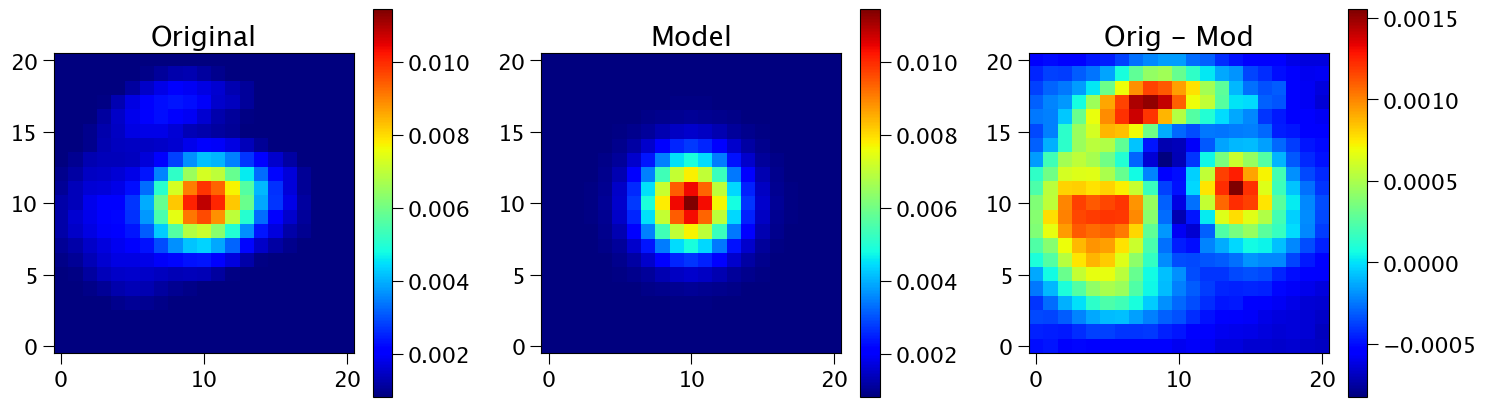

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 58.350866381494306 mas
c0153_psf.fits 1 5.082730439442657 48.98087647818499 49.00674478281488 21.0
peak flux ratio =  0.010816668  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0153_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0153_psf.fits                  -1.000    -1.0   -1.00  57114.4936

box size going into fit_gaussian2d() : 21.0


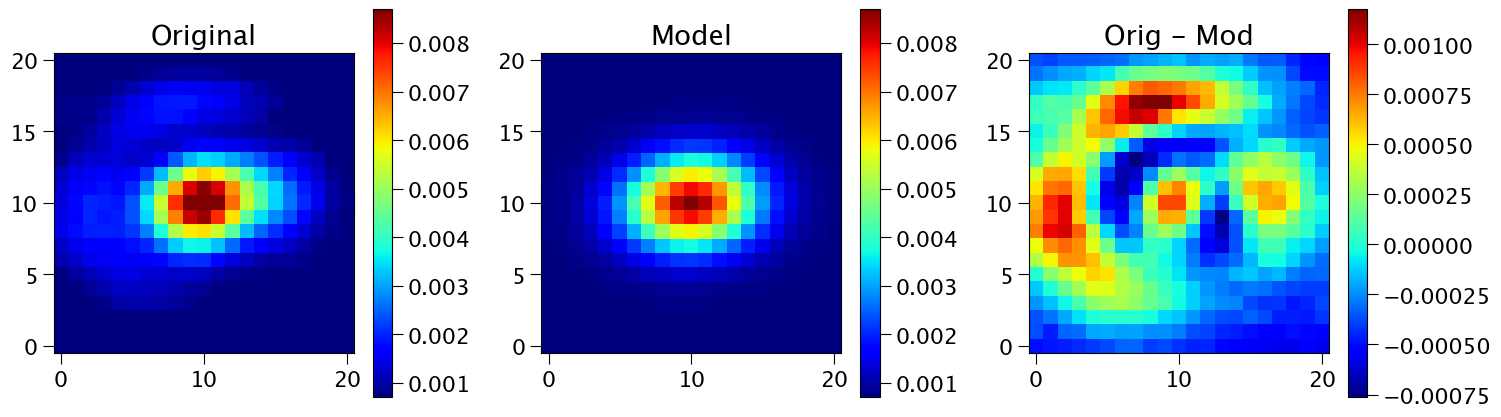

FWHM on iteration 1 = 61.93 mas | Empirical FWHM on iteration 1 = 58.350866381494306 mas
c0156_psf.fits 1 6.222801051593002 49.03131677521389 49.01251183169361 21.0
peak flux ratio =  0.009551777  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0156_psf.fits   0.260   392.6   61.93   49.5   49.5

c0156_psf.fits                   0.260   392.6   61.93  57114.4963

box size going into fit_gaussian2d() : 21.0


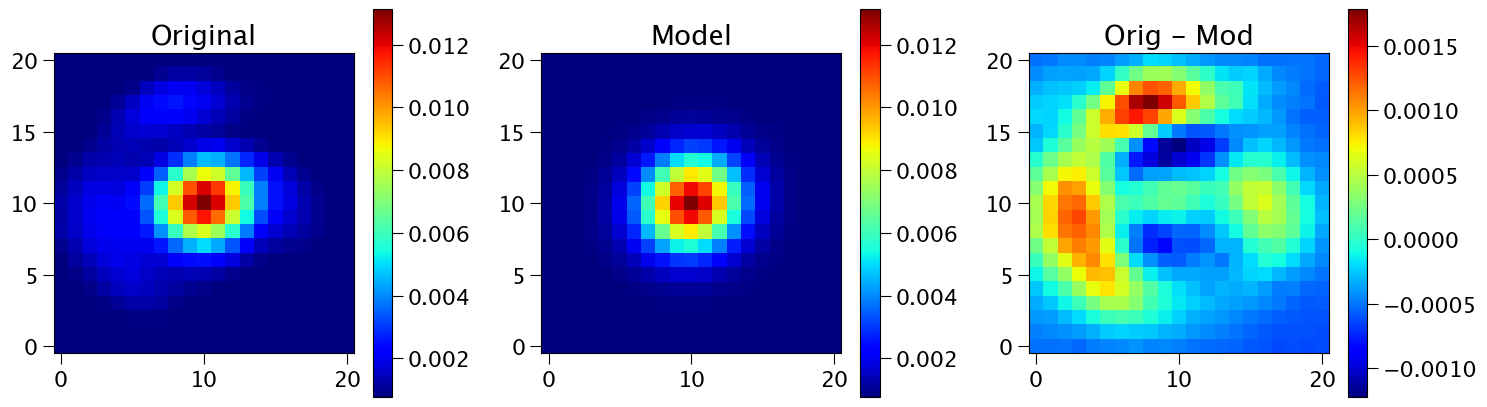

FWHM on iteration 1 = 52.98 mas | Empirical FWHM on iteration 1 = 51.46062707686444 mas
c0159_psf.fits 1 5.323549678744634 49.02576733652033 49.00923454183162 21.0
peak flux ratio =  0.013296036  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0159_psf.fits   0.362   341.1   52.98   49.5   49.5

c0159_psf.fits                   0.362   341.1   52.98  57114.4993

box size going into fit_gaussian2d() : 21.0


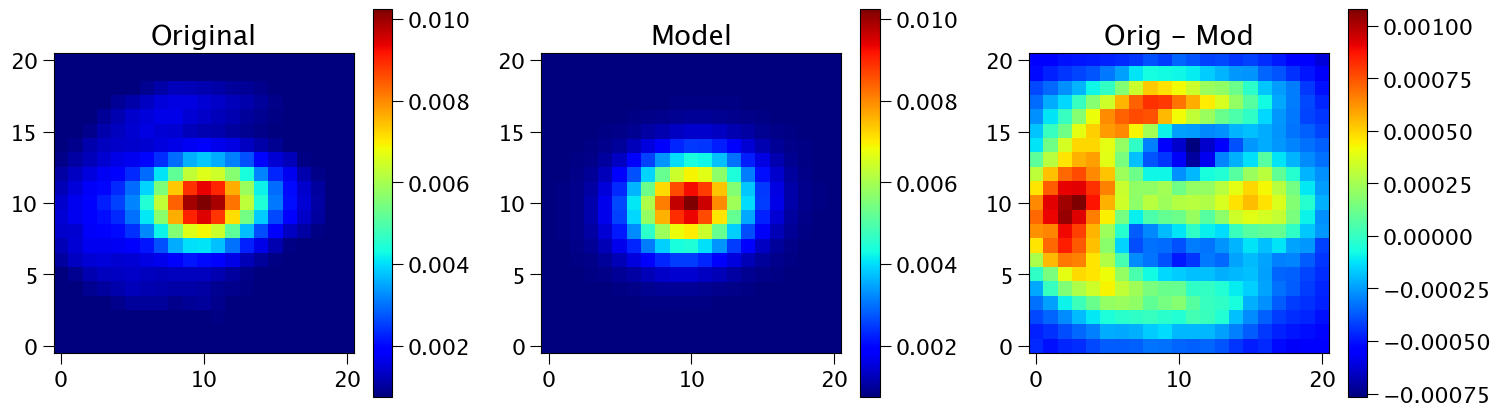

FWHM on iteration 1 = 57.85 mas | Empirical FWHM on iteration 1 = 60.47340542403716 mas
c0162_psf.fits 1 5.812604841870032 48.957495499408395 48.97879198157056 21.0
peak flux ratio =  0.010517972  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0162_psf.fits   0.286   378.3   57.85   49.5   49.5

c0162_psf.fits                   0.286   378.3   57.85  57114.5019

box size going into fit_gaussian2d() : 21.0


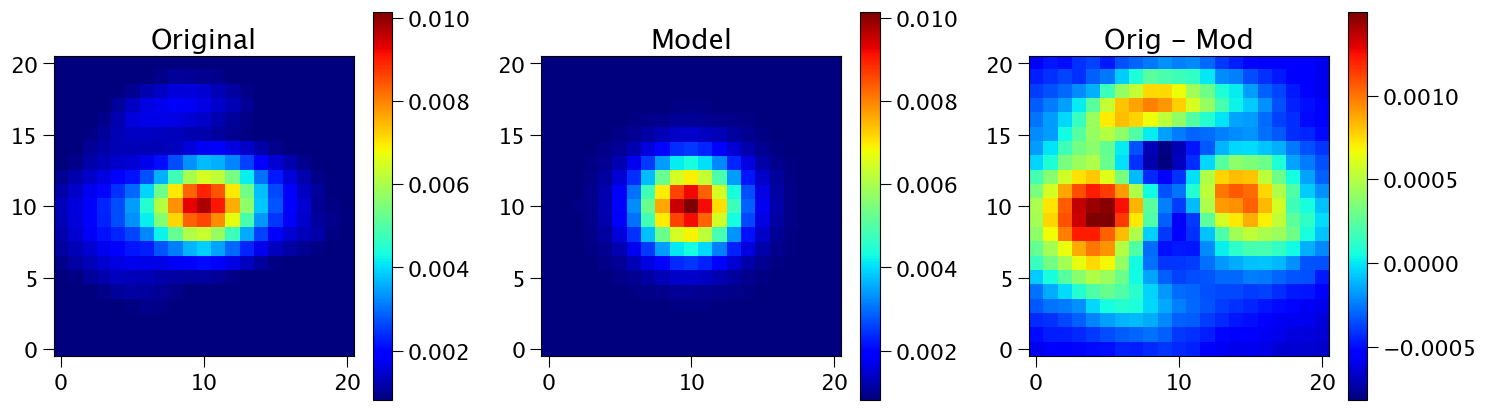

FWHM on iteration 1 = 53.11 mas | Empirical FWHM on iteration 1 = 60.47340542403716 mas
c0165_psf.fits 1 5.3371060017723835 48.88205715944768 49.007345494842696 21.0
peak flux ratio =  0.009738481  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0165_psf.fits   0.265   389.8   53.11   49.5   49.5

c0165_psf.fits                   0.265   389.8   53.11  57114.5045

box size going into fit_gaussian2d() : 21.0


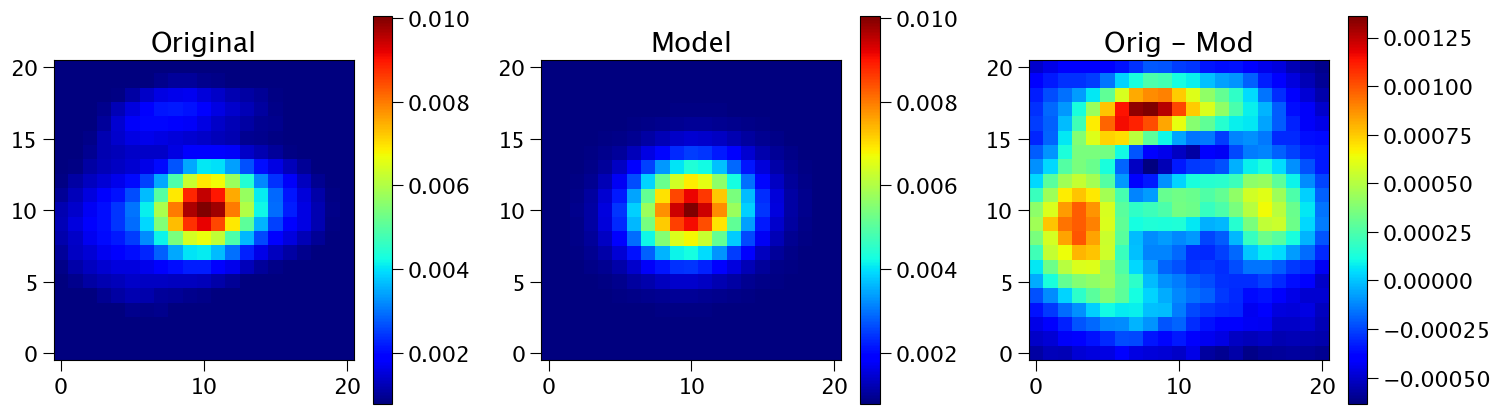

FWHM on iteration 1 = 56.95 mas | Empirical FWHM on iteration 1 = 58.350866381494306 mas
c0168_psf.fits 1 5.722720277173276 49.00451438458262 49.01982917599661 21.0
peak flux ratio =  0.010381809  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0168_psf.fits   0.282   380.3   56.95   49.5   49.5

c0168_psf.fits                   0.282   380.3   56.95  57114.5111

box size going into fit_gaussian2d() : 21.0


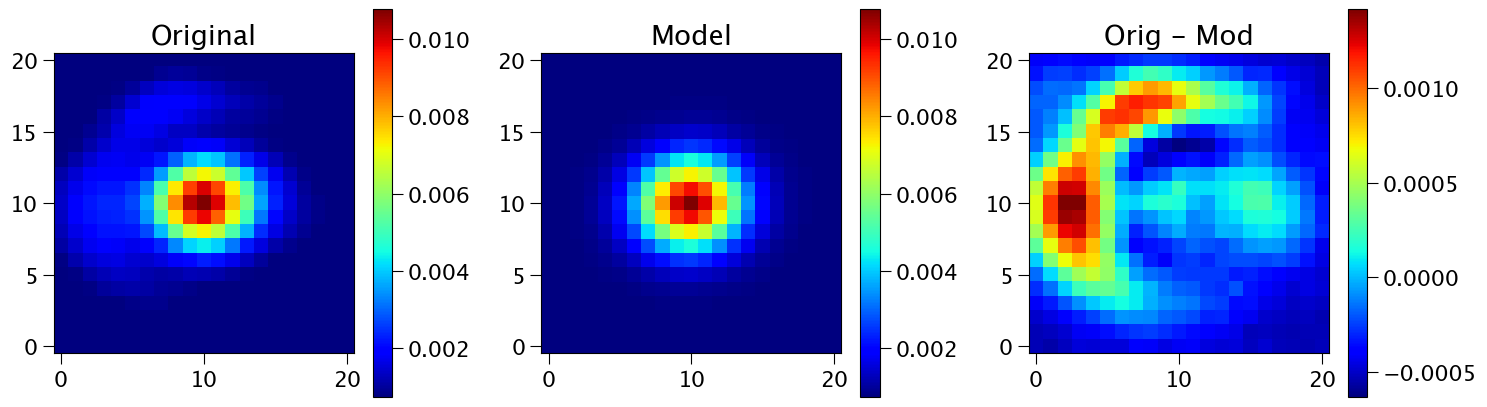

FWHM on iteration 1 = 54.78 mas | Empirical FWHM on iteration 1 = 55.0137244086197 mas
c0171_psf.fits 1 5.504032605339239 48.93969640050284 48.98949867792923 21.0
peak flux ratio =  0.010920344  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0171_psf.fits   0.297   372.6   54.78   49.5   49.5

c0171_psf.fits                   0.297   372.6   54.78  57114.5137

box size going into fit_gaussian2d() : 21.0


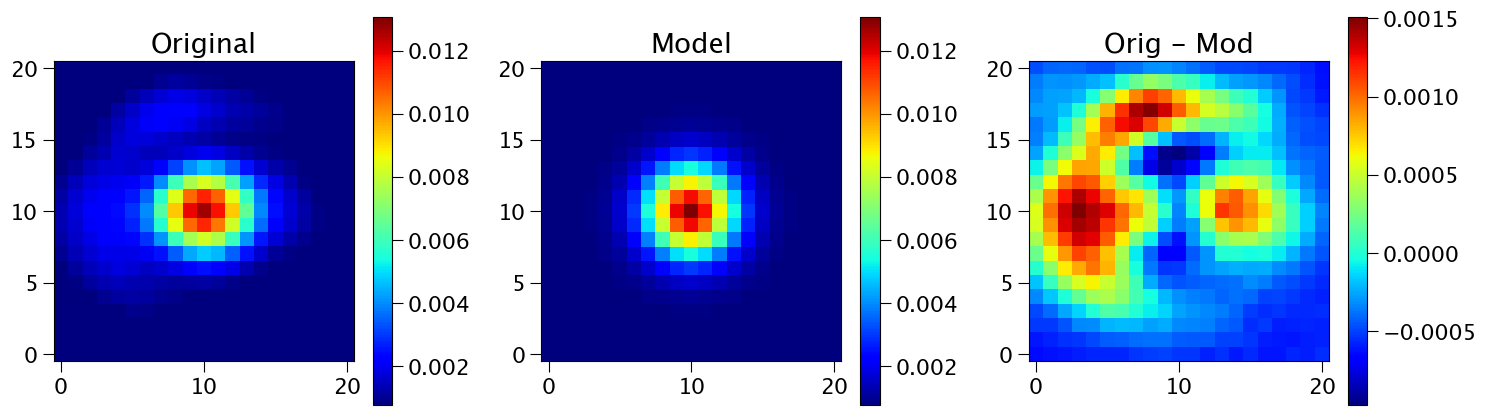

FWHM on iteration 1 = 50.58 mas | Empirical FWHM on iteration 1 = 52.67163104744902 mas
c0174_psf.fits 1 5.082730439442657 48.97729187141183 48.9943009938028 21.0
peak flux ratio =  0.0127107315  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0174_psf.fits  -1.000    -1.0   -1.00   49.5   49.5

c0174_psf.fits                  -1.000    -1.0   -1.00  57114.5163

box size going into fit_gaussian2d() : 21.0


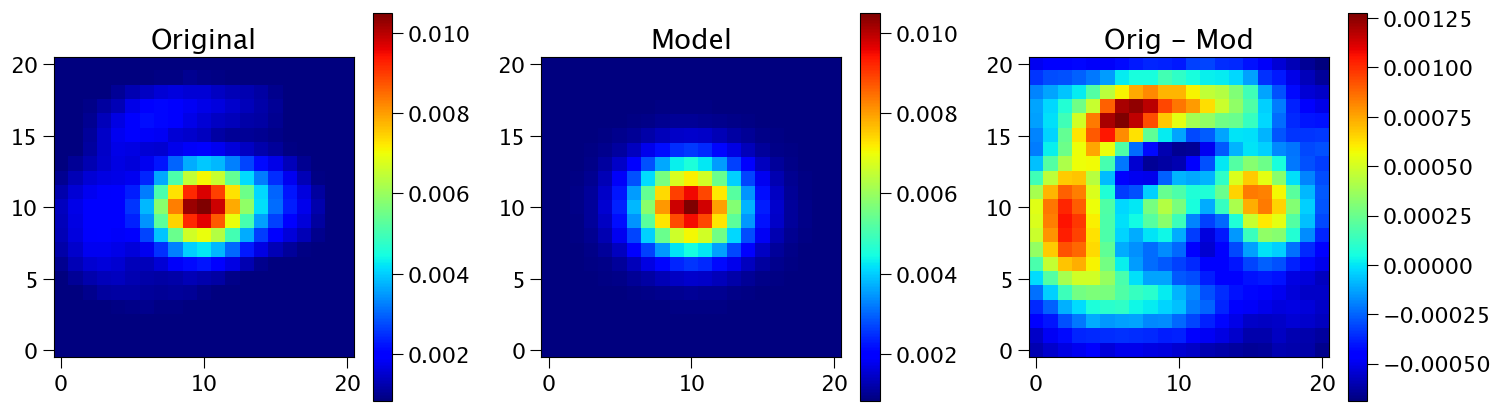

FWHM on iteration 1 = 55.75 mas | Empirical FWHM on iteration 1 = 56.14814735467271 mas
c0177_psf.fits 1 5.602174596065055 48.98719463521431 49.0130544397203 21.0
peak flux ratio =  0.010774257  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0177_psf.fits   0.293   374.7   55.75   49.5   49.5

c0177_psf.fits                   0.293   374.7   55.75  57114.5191

box size going into fit_gaussian2d() : 21.0


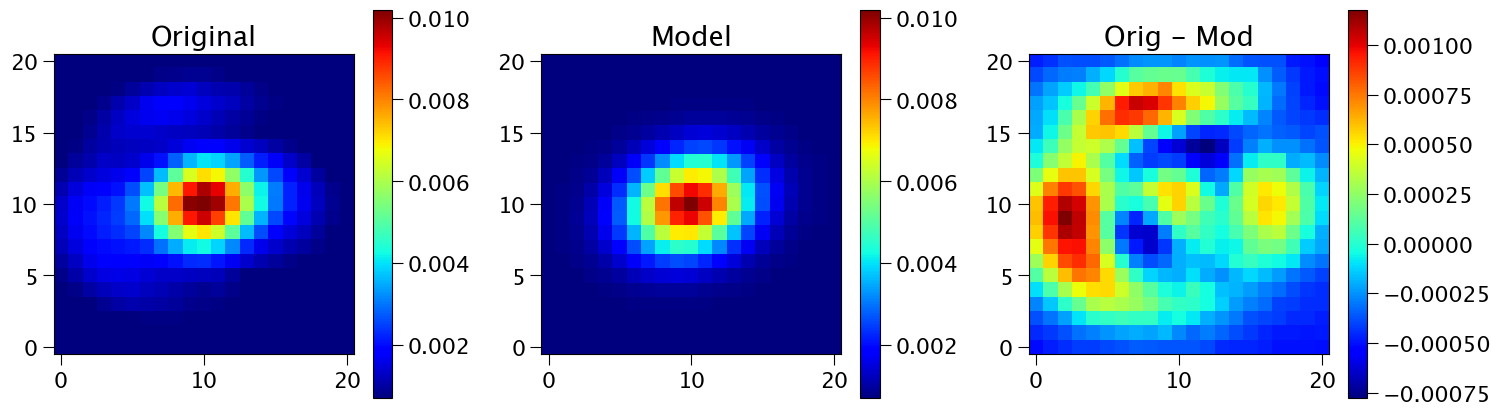

FWHM on iteration 1 = 59.31 mas | Empirical FWHM on iteration 1 = 59.421613790989255 mas
c0180_psf.fits 1 5.959251185967909 48.95101044621384 48.987049490124015 21.0
peak flux ratio =  0.0107447775  dl peak flux ratio =  0.036778376
/g/lu/data/m53/2015apr/clean/kp/c0180_psf.fits   0.292   375.1   59.31   49.5   49.5

c0180_psf.fits                   0.292   375.1   59.31  57114.5217



In [44]:
sky_strehls, sky_fwhms, sky_rmswfes, sky_emp_fwhms = mu.calc_strehl_on_sky(psf_fits, "temp.txt")

In [51]:
sky_strehls = np.array(sky_strehls)
sky_fwhms = np.array(sky_fwhms)
sky_rmswfes = np.array(sky_rmswfes)
sky_emp_fwhms = np.array(sky_emp_fwhms)

In [62]:
# Simulate frames in MAOS that did NOT fail gracefully 
# within sky metric function calc_strehl_on_sky()
i = (sky_strehls != -1.0).nonzero()[0]
np.array(psf_fits)[i]

array(['/g/lu/data/m53/2015may/clean/kp/c0016_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0019_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0022_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0025_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0028_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0031_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0034_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0037_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0040_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0043_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0046_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0049_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0064_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0070_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0094_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0103_psf.fits',
       '/g/lu/data/m53/2015may/clean/kp/c0106_psf.fits',
       '/g/lu/data/m53/2015may/

In [63]:
len(np.array(psf_fits)[i])

62

In [ ]:
# Simulation seeds
seeds = np.array([1, 1000, 5000, 10000])
# Simulation types/modes (exclude piston in interest of time)
simtypes = ['psd+ncpa-unseen', 'psd+ncpa-seen']
baseroot = Path("/Users/bdigia/work/ao/keck/maos/keck/my_base/")
# Run simulation for each KOA image in koa_file array
for m53 in psf_fits:
    with fits.open(m53) as m53_fits:
        hdu = m53_fits[0]
        hdr = hdu.header

        # Zenith angle
        angle = np.degrees(np.arccos(1.0/float(hdr['AIRMASS'])))
        thetax = [0.0, 0.0, 0.0] # arcsec, on-axis
        thetay = [0.0, 0.0, 0.0] # arcsec, on-axis
        # Calculate atm parameters
        fried, turbpro, windspds, winddrcts, _, _, _, _, _, _ = mu.estimate_on_sky_conditions(m53_fits, 
                                                                                              "/Users/bdigia/work/ao/airopa_input/m53_weather/", 
                                                                                              verbose=True)

        # Wavelength at which to run MAOS (microns)
        wvl = float(hdr['TARGWAVE']) * 1.0e-6 # multiply by 1e-6 to convert from microns to m
        # STRAP WFS integration time (milli-sec)
        if 'STINTTIM' not in hdr:
            continue
        hdr_strap_int_time = float(hdr['STINTTIM'])
        # SHWFS frame rate (Hz)
        hdr_shwfs_frame_rate = float(hdr['WSFRRT'])
        hdr_strap_frame_rate = (1.0/hdr_strap_int_time)*1000.0

        # Set sim_dt to fastest WFS readout rate in Hz
        if hdr_shwfs_frame_rate > hdr_strap_frame_rate:
            max_frame_rate = hdr_shwfs_frame_rate
            print(f"SHWFS frame rate is maximum = {max_frame_rate} Hz >= {hdr_strap_frame_rate}")
        else:
            max_frame_rate = hdr_strap_frame_rate
            print(f"STRAP frame rate is maximum = {max_frame_rate} Hz >= {hdr_shwfs_frame_rate}")

        sim_dt = 1.0/max_frame_rate
        hdr_shwfs_int_time = (1.0/hdr_shwfs_frame_rate)*1000.0 # ms

        howfs_dtrat = (sim_dt / hdr_shwfs_int_time)*1000.0
        strap_dtrat = (sim_dt / hdr_strap_int_time)*1000.0
        # Compose powfs.dtrat array for input into MAOS config command override
        if howfs_dtrat < 1:
            howfs_dtrat = 1
        elif strap_dtrat < 1:
            strap_dtrat = 1
        dtrat = [int(howfs_dtrat), int(strap_dtrat), 7080]
        
        # Calculate siglev/bkgrnd/nearecon config parameters using variable
        # integration times from headers and mag of KOA guide star (KOA engcalib
        # images have LGS == NGS)
        _, howfs_nearecon, howfs_siglev, howfs_bkgrnd = mu.keck_nea_photons(8.1, 'LGSWFS', 
                                                                            hdr_shwfs_int_time/1000.0) # convert to sec
        # TT brightness 13.8 from M53 google doc 
        # (https://docs.google.com/document/d/1iR1HZFA8g_JKQRhLZjjqWTHm6wMx7gSlf-0AThMYuZw/edit#heading=h.j4vt5w648zy)
        _, strap_nearecon, strap_siglev, strap_bkgrnd = mu.keck_nea_photons(13.8, 'STRAP', 
                                                                            hdr_strap_int_time/1000.0) # convert to sec
        nearecon = [howfs_nearecon, strap_nearecon, 8.4]
        siglev = [howfs_siglev, strap_siglev, 3723]
        bkgrnd = [howfs_bkgrnd, strap_bkgrnd, 25.3]

        for seed in seeds:
            for mode in simtypes:
                if mode == 'piston':
                    surf_cmd = ["Keck_ncpa_rmswfe130nm.fits"]
                    # Fetch name of current input PSD FITS file in MAOS config file keck_sim.conf
                    psd_file = ''
                elif mode == 'psd+ncpa-seen':
                    mode = 'surf_wfs1'
                    surf_cmd = ["Keck_ncpa_rmswfe130nm.fits", "'r0=0.36;l0=3.39;ht=40000;slope=-2; SURFWFS=1; SURFEVL=1; seed=10;'"]
                    psd_file = "PSD_Keck_ws26.47mas_vib26mas_rad2.fits"
                elif mode == 'psd+ncpa-unseen':
                    mode = 'surf_wfs0'
                    surf_cmd = ["Keck_ncpa_rmswfe130nm.fits", "'r0=0.36;l0=3.39;ht=40000;slope=-2; SURFWFS=0; SURFEVL=1; seed=10;'"]
                    psd_file = "PSD_Keck_ws26.47mas_vib26mas_rad2.fits"
                else:
                    raise ValueError(f"Invalid MAOS simulation type '{type}'. Valid types are currently: 'piston', 'psd+ncpa-seen', 'psd+ncpa-unseen'. See help() for further info")
        
                # Must be in MAOS simulation directory to run successfully
                if os.getcwd() != baseroot.as_posix():
                    os.chdir(baseroot)

                maos_cmd = f"maos -o A_keck_scao_lgs_koa_{mode}_comp_{koa[60:65]}_seed{seed}_epoch{koa[51:59]} -c A_keck_scao_lgs.conf sim.seeds={seed} evl.wvl={wvl} sim.dt={sim_dt} sim.dtref={sim_dt} powfs.dtrat={dtrat} sim.zadeg={angle} powfs.siglev={siglev} powfs.bkgrnd={bkgrnd} powfs.nearecon={nearecon} sim.zadeg={angle} sim.wspsd={psd_file} atm.r0z={fried.value} atm.wt={turbpro} atm.ws={windspds} atm.wddeg={winddrcts} surf={surf_cmd} -O"
                # os.system(maos_cmd)